# 1. Purpose of this notebook

This notebook evaluates standard request-agnostic SISA as a backup experiment. A **shard** is an independent training partition with its own constituent model. A **slice** is an ordered stage inside a shard, used to create recovery checkpoints; slices do not become separate models. Each checkpoint is trained cumulatively on all shard data available so far, and the five final constituent probabilities are averaged.

Assignments are fixed before deletion requests are applied. In principle, an affected shard can be rebuilt from its last unaffected checkpoint after removing forgotten training rows.


In [1]:
# Import only the libraries required by the established notebook workflow.
import pandas as pd
from IPython.display import display

sisa_terms = pd.DataFrame([
    {"term": "Sharded", "meaning": "training recipients are partitioned across independent models"},
    {"term": "Isolated", "meaning": "a shard is trained without records assigned to other shards"},
    {"term": "Sliced", "meaning": "each shard is learned through five replayable stages"},
    {"term": "Aggregated", "meaning": "five shard probabilities are averaged with equal weights"},
])
display(sisa_terms)

,term,meaning
0,Sharded,training recipients are partitioned across ind...
1,Isolated,a shard is trained without records assigned to...
2,Sliced,each shard is learned through five replayable ...
3,Aggregated,five shard probabilities are averaged with equ...


The aim is to determine whether SISA supports efficient selective deletion while preserving utility and approximating full-retraining behaviour.

1. How many shards and slices does each deletion affect?
2. How much retained utility is preserved?
3. How similar is updated SISA to full retraining on forget records?
4. How does SISA compare with fine-tuning and gradient ascent?
5. What is the deletion-time saving?
6. What initial training and storage cost is required?


In [2]:
# Replay only the affected shard suffix while preserving the frozen assignment.
study_design = pd.DataFrame([
    {"objective": "Deletion structure", "evaluation": "affected shards and replayed stages", "comparison": "five fixed scenarios"},
    {"objective": "Retained utility", "evaluation": "held-out retained-test metrics", "comparison": "four existing methods and original SISA"},
    {"objective": "Forget behaviour", "evaluation": "truth-ratio KS and supporting measures", "comparison": "full retraining, fine-tuning, gradient ascent"},
    {"objective": "Efficiency", "evaluation": "preparation, replay time and storage", "comparison": "full retraining, fine-tuning, gradient ascent"},
])
display(study_design)

,objective,evaluation,comparison
0,Deletion structure,affected shards and replayed stages,five fixed scenarios
1,Retained utility,held-out retained-test metrics,four existing methods and original SISA
2,Forget behaviour,truth-ratio KS and supporting measures,"full retraining, fine-tuning, gradient ascent"
3,Efficiency,"preparation, replay time and storage","full retraining, fine-tuning, gradient ascent"


**Scope.**

The authoritative dataset, permanent splits and five deletion scenarios remain unchanged. Complete recipient histories stay together. Shard and slice assignments are fixed before deletion evaluation, and threshold `0.62` is retained. Existing methods are read-only references. Initial preparation and deletion-time cost are reported separately. Output similarity is not proof of erasure or privacy, and generated-data results are not clinical evidence.


# 2. Load frozen data and comparison artefacts

Only local data, modelling, statistics, plotting and hashing libraries are used; no API or network library is imported.


In [3]:
# Import only the libraries required by the established notebook workflow.
import copy
import hashlib
import json
import random
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display
from scipy.stats import ks_2samp


In [4]:
# Import only the libraries required by the established notebook workflow.
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    confusion_matrix, f1_score, log_loss, precision_score,
    recall_score, roc_auc_score,
)
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

The submission root is located without a machine-specific path. Existing artifacts are read-only. This notebook creates only the standard hash-based assignment, model directories and result directory.


In [5]:
# Keep paths portable inside the submission workspace.
def locate_submission_root():
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents, cwd / "final_submission"]:
        direct = candidate / "data/final/kidney_transplant_assessments.csv"
        nested = candidate / "final_submission/data/final/kidney_transplant_assessments.csv"
        if direct.is_file(): return candidate
        if nested.is_file(): return candidate / "final_submission"
    raise FileNotFoundError("Could not locate final_submission")

ROOT = locate_submission_root()
DATA_PATH = ROOT / "data/final/kidney_transplant_assessments.csv"
FEATURE_PATH = ROOT / "data/final/classifier_feature_list.json"
SPLIT_PATH = ROOT / "processed_data/split_assignments.csv"
MEMBERSHIP_PATH = ROOT / "processed_data/deletion_scenario_membership.csv"
ASSIGNMENT_PATH = ROOT / "processed_data/sisa/hash_based/sisa_shard_slice_assignment.csv"
BASELINE_DIR = ROOT / "models/baseline"


In [6]:
# Keep shard and slice operations explicit so SISA provenance remains auditable.
FULL_DIR = ROOT / "results/full_retraining"
FINE_DIR = ROOT / "results/retain_set_fine_tuning"
GRADIENT_DIR = ROOT / "results/gradient_ascent"
MODEL_DIR = ROOT / "models/sisa/hash_based"
ORIGINAL_DIR = MODEL_DIR / "original"
UNLEARNED_DIR = MODEL_DIR / "unlearned"
RESULT_DIR = ROOT / "results/sisa/hash_based"
FIGURE_DIR = RESULT_DIR / "figures"
for path in [ASSIGNMENT_PATH.parent, ORIGINAL_DIR, UNLEARNED_DIR, RESULT_DIR, FIGURE_DIR]:
    path.mkdir(parents=True, exist_ok=True)
_ = (RESULT_DIR / "run_summary.json").write_text(
    json.dumps({"status": "running", "task": "SISA"}, indent=2) + "\n"
)

In [7]:
# Fingerprint every frozen input before SISA writes its own outputs.
protected_paths = [DATA_PATH, ROOT / "data/final/kidney_transplant_identity.csv", FEATURE_PATH,
                   SPLIT_PATH, MEMBERSHIP_PATH]
for directory in [BASELINE_DIR, ROOT / "results/baseline", ROOT / "models/full_retraining", FULL_DIR,
                  ROOT / "models/retain_set_fine_tuning", FINE_DIR,
                  ROOT / "models/gradient_ascent", GRADIENT_DIR]:
    protected_paths += sorted(path for path in directory.rglob("*") if path.is_file())
protected_paths += [ROOT / "notebooks" / name for name in [
    "00_dataset_generation.ipynb", "01_baseline_model.ipynb",
    "02_deletion_scenarios_and_full_retraining.ipynb",
    "03_retain_set_fine_tuning.ipynb", "04_gradient_ascent.ipynb"]]

def sha256_file(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()

input_hashes_before = {path.relative_to(ROOT).as_posix(): sha256_file(path) for path in protected_paths}
display(pd.DataFrame(input_hashes_before.items(), columns=["protected_input", "sha256"]).head(10))

,protected_input,sha256
0,data/final/kidney_transplant_assessments.csv,ec6c6265fc7ed7674c2950316efefb74546b04a817e37f...
1,data/final/kidney_transplant_identity.csv,f795a8310732222ad07817cf1a983514a24f9eb6604afd...
2,data/final/classifier_feature_list.json,9fd5fde0ac22707a8dd9f5fe11da688aba8bca9a95b630...
3,processed_data/split_assignments.csv,fde3ab5bfd16abb18191b4b10619f2d1a651006896325c...
4,processed_data/deletion_scenario_membership.csv,76ba6f3fb6a919352f51d4db636875a242a25440e088fd...
5,models/baseline/baseline_model.pt,f91581e9ed02593c50b6ce538791f8b7fb2bb23361ede1...
6,models/baseline/baseline_preprocessor.joblib,e93f3d0249e457e57575f40182f7b2647653794ea3dba8...
7,models/baseline/model_configuration.json,b3905f26078c8d910852d70f3ac90287c4f69eb010c3a9...
8,models/baseline/processed_feature_order.json,3fc2fadf3be2159fa8605f461bf9b0fc12d222aed451d5...
9,results/baseline/baseline_attempt_001_failure_...,d25e5e5d98721a5324185dbe7c87eec2a392588b304cbf...


Seed 42 controls the study. Derived assignment, shard and replay seeds are calculated by SHA-256 rather than manually chosen.


In [8]:
# Use deterministic seeds for assignment, initialisation and replay.
SEED = 42
DEVICE = torch.device("cpu")

def derived_seed(*parts):
    text = ":".join(map(str, (SEED, *parts)))
    return int(hashlib.sha256(text.encode()).hexdigest()[:8], 16)

def slice_training_seed(shard_id, slice_id):
    """Return the scenario-independent seed for one shard/slice training stage."""
    return derived_seed("slice_training", shard_id, slice_id)

def reset_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

reset_seed()
torch.use_deterministic_algorithms(True)
torch.set_num_threads(1)

The authoritative records, 18-feature contract and recipient-level permanent split are validated before assignment.


In [9]:
# Load the approved feature contract and permanent recipient split unchanged.
assessments = pd.read_csv(DATA_PATH)
feature_contract = json.loads(FEATURE_PATH.read_text())
features = feature_contract["classifier_features"]
target = feature_contract["target"]
splits = pd.read_csv(SPLIT_PATH)
assert assessments.shape == (60_000, 31)
assert assessments["recipient_id"].nunique() == 10_000
assert assessments.groupby("recipient_id").size().eq(6).all()
assert len(features) == 18 and splits["recipient_id"].is_unique
assert splits["recipient_id"].nunique() == 10_000 and set(splits["split"]) == {"train", "validation", "test"}
split_map = splits.set_index("recipient_id")["split"]
assessments["original_split"] = assessments["recipient_id"].map(split_map)
assert assessments["original_split"].notna().all()
split_sets = {name: set(splits.loc[splits["split"].eq(name), "recipient_id"])
              for name in ["train", "validation", "test"]}


In [10]:
assert all(split_sets[a].isdisjoint(split_sets[b]) for a,b in
           [("train","validation"),("train","test"),("validation","test")])
display(assessments.groupby("original_split").agg(rows=("assessment_id","size"), recipients=("recipient_id","nunique")))

,rows,recipients
original_split,,
test,8988,1498
train,42024,7004
validation,8988,1498


# 3. Reconstruct deletion scenarios

Membership IDs are unique within scenario and map to the correct split. Boolean masks always come from the DataFrame being indexed.


In [11]:
# Reuse the five deletion memberships defined by Notebook 02.
SCENARIOS = ["recipient_withdrawal", "donor_withdrawal", "hospital_removal",
             "invalid_consent", "retention_expiry"]
EXPECTED_TRAINING_FORGET_COUNTS = {"recipient_withdrawal":426, "donor_withdrawal":1992,
    "hospital_removal":4314, "invalid_consent":4148, "retention_expiry":6262}
membership = pd.read_csv(MEMBERSHIP_PATH)
assert not membership.duplicated(["scenario","assessment_id"]).any()
training_membership = membership.loc[membership["membership_type"].eq("training_forget")]
assert training_membership.groupby("scenario").size().to_dict() == EXPECTED_TRAINING_FORGET_COUNTS
assert set(membership["assessment_id"]).issubset(set(assessments["assessment_id"]))
scenario_frames = {}


In [12]:
# Keep shard and slice operations explicit so SISA provenance remains auditable.
for scenario in SCENARIOS:
    sm = membership.loc[membership["scenario"].eq(scenario)]
    parts = {}
    for split_name, deleted_name, retained_name in [("train","training_forget","retained_train"),
            ("validation","deleted_validation","retained_validation"),("test","deleted_test","retained_test")]:
        base = assessments.loc[assessments["original_split"].eq(split_name)]
        deleted_ids = set(sm.loc[sm["membership_type"].eq(deleted_name), "assessment_id"])
        mask = base["assessment_id"].isin(deleted_ids)
        parts[deleted_name], parts[retained_name] = base.loc[mask].copy(), base.loc[~mask].copy()
        assert len(parts[deleted_name]) + len(parts[retained_name]) == len(base)
    scenario_frames[scenario] = parts

SISA reuses the baseline preprocessor as a fixed shared representation, but it does not load baseline parameters. Every shard starts from fresh seeded weights. The preprocessor was fitted before deletion and is not itself unlearned.


In [13]:
# Each shard uses the same architecture but starts from fresh weights.
class BaselineMLP(nn.Module):
    def __init__(self, input_dim=24, hidden_dims=(64,32), dropout=.10):
        super().__init__()
        self.network = nn.Sequential(nn.Linear(input_dim,hidden_dims[0]), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dims[0],hidden_dims[1]), nn.ReLU(), nn.Dropout(dropout), nn.Linear(hidden_dims[1],1))
    def forward(self, x): return self.network(x).squeeze(1)

baseline_config = json.loads((BASELINE_DIR / "model_configuration.json").read_text())
preprocessor = joblib.load(BASELINE_DIR / "baseline_preprocessor.joblib")
THRESHOLD = float(baseline_config["threshold"])
probe_model = BaselineMLP()
assert [24,*baseline_config["hidden_dims"],1] == [24,64,32,1]
assert sum(p.numel() for p in probe_model.parameters()) == baseline_config["parameter_count"] == 3713
assert baseline_config["input_dim_processed"] == 24 and baseline_config["classifier_features"] == features
assert THRESHOLD == .62

Completed full-retraining, fine-tuning and gradient-ascent outputs are read without rerunning them.


In [14]:
# Load comparison results without rerunning the main-study methods.
full_summary = json.loads((FULL_DIR / "run_summary.json").read_text())
fine_summary = json.loads((FINE_DIR / "run_summary.json").read_text())
gradient_summary = json.loads((GRADIENT_DIR / "run_summary.json").read_text())
assert full_summary["status"] == fine_summary["status"] == gradient_summary["status"] == "completed"
full_test = pd.read_csv(FULL_DIR / "retained_test_predictions.csv")
full_forget = pd.read_csv(FULL_DIR / "forget_set_reference_predictions.csv")
full_training = pd.read_csv(FULL_DIR / "training_summary.csv")
fine_test = pd.read_csv(FINE_DIR / "retained_test_predictions.csv")
fine_forget = pd.read_csv(FINE_DIR / "forget_set_predictions.csv")
fine_training = pd.read_csv(FINE_DIR / "training_summary.csv")
fine_quality = pd.read_csv(FINE_DIR / "forget_quality.csv")
gradient_test = pd.read_csv(GRADIENT_DIR / "retained_test_predictions.csv")
gradient_forget = pd.read_csv(GRADIENT_DIR / "forget_set_predictions.csv")
gradient_utility_reference = pd.read_csv(GRADIENT_DIR / "utility_metrics.csv")
gradient_training = pd.read_csv(GRADIENT_DIR / "training_summary.csv")


In [15]:
gradient_quality = pd.read_csv(GRADIENT_DIR / "forget_quality.csv")
EPSILON = float(pd.read_csv(FULL_DIR / "truth_ratio_reference_values.csv")["epsilon"].iloc[0])

The gate covers dependencies, architecture, split and membership contracts, row alignment and leakage. Assignment cannot begin unless every row passes.


In [16]:
# Exclude identifiers, assignment fields and audit attributes from modelling.
direct_fields = {"recipient_id","donor_id","hospital_id","assessment_id","full_name","date_of_birth",
                 "email_address","postcode","hospital_number","training_consent_status",
                 "training_consent_version","retention_expiry_date","shard_id","slice_id"}


In [17]:
# Keep shard and slice operations explicit so SISA provenance remains auditable.
checks = [
    {"check":"required protected files", "pass":all(path.is_file() for path in protected_paths)},
    {"check":"completed reference statuses", "pass":full_summary["status"]==fine_summary["status"]==gradient_summary["status"]=="completed"},
    {"check":"five scenarios", "pass":set(SCENARIOS)==set(gradient_training["scenario"])},
    {"check":"feature order", "pass":features==baseline_config["classifier_features"]},
    {"check":"processed dimension", "pass":baseline_config["input_dim_processed"]==24},
    {"check":"architecture and parameters", "pass":baseline_config["hidden_dims"]==[64,32] and baseline_config["parameter_count"]==3713},
    {"check":"threshold", "pass":THRESHOLD==.62},
    {"check":"split coverage", "pass":assessments["original_split"].notna().all()},
    {"check":"membership counts", "pass":training_membership.groupby("scenario").size().to_dict()==EXPECTED_TRAINING_FORGET_COUNTS},
    {"check":"membership IDs and uniqueness", "pass":not membership.duplicated(["scenario","assessment_id"]).any()},
    {"check":"identifiers excluded", "pass":direct_fields.isdisjoint(features)},
]
artifact_checks = pd.DataFrame(checks)

In [18]:
# Align retained-test and training-forget rows with the frozen references.
for scenario in SCENARIOS:
    test = scenario_frames[scenario]["retained_test"].reset_index(drop=True)
    forget = scenario_frames[scenario]["training_forget"].reset_index(drop=True)
    ft = full_test.loc[full_test["scenario"].eq(scenario)].reset_index(drop=True)
    ff = full_forget.loc[full_forget["scenario"].eq(scenario)].reset_index(drop=True)
    nt = fine_test.loc[fine_test["scenario"].eq(scenario)].sort_values("evaluation_row")
    nf = fine_forget.loc[fine_forget["scenario"].eq(scenario)].sort_values("evaluation_row")
    gt = gradient_test.loc[gradient_test["scenario"].eq(scenario)].sort_values("evaluation_row")
    artifact_checks.loc[len(artifact_checks)] = [f"{scenario}: retained-test alignment",
        list(test["assessment_id"])==list(ft["assessment_id"]) and
        np.array_equal(test[target],nt["true_target"]) and np.array_equal(test[target],gt["true_target"])]
    artifact_checks.loc[len(artifact_checks)] = [f"{scenario}: training-forget alignment",
        list(forget["assessment_id"])==list(ff["assessment_id"]) and np.array_equal(forget[target],nf["true_target"])]
    artifact_checks.loc[len(artifact_checks)] = [f"{scenario}: reference counts",
        len(test)==len(ft)==len(nt)==len(gt) and len(forget)==len(ff)==len(nf)]


In [19]:
assert artifact_checks["pass"].all()
display(artifact_checks.assign(status=artifact_checks["pass"].map({True:"PASS",False:"FAIL"})).drop(columns="pass"))

,check,status
0,required protected files,PASS
1,completed reference statuses,PASS
2,five scenarios,PASS
3,feature order,PASS
4,processed dimension,PASS
5,architecture and parameters,PASS
6,threshold,PASS
7,split coverage,PASS
8,membership counts,PASS
9,membership IDs and uniqueness,PASS


All 26 dependency and alignment checks passed. Existing methods remained read-only references, and direct identifiers, assignment fields and audit attributes were excluded.


# 4. Define the SISA design

One configuration is frozen before deletion evaluation: five shards, five slices, AdamW, weighted BCE and the shared 24-dimensional representation.


In [20]:
# Freeze the SISA design before examining deletion effects.
N_SHARDS = 5
N_SLICES = 5
BATCH_SIZE = 512
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
MAX_EPOCHS_PER_SLICE = 12
EARLY_STOPPING_PATIENCE = 3

Only permanent training recipients are assigned. A SHA-256 digest of seed, assignment type and recipient ID determines the shard; target, hospital, donor, membership and performance are absent.


In [21]:
# Assign recipients before applying any deletion request.
def stable_group(recipient_id, kind, groups):
    digest = hashlib.sha256(f"{SEED}:{kind}:{recipient_id}".encode()).hexdigest()
    return int(digest,16) % groups + 1

train_recipients = sorted(split_sets["train"])
assignment = pd.DataFrame({"recipient_id":train_recipients})
assignment["shard_id"] = assignment["recipient_id"].map(lambda value:stable_group(value,"shard",N_SHARDS))
assert assignment["recipient_id"].is_unique and assignment["shard_id"].between(1,N_SHARDS).all()

A second independent stable digest assigns one slice within the recipient's shard. All six assessments therefore share both audit-only values.


In [22]:
# Keep every assessment for one recipient inside one shard and slice.
assignment["slice_id"] = assignment["recipient_id"].map(lambda value:stable_group(value,"slice",N_SLICES))
assignment.to_csv(ASSIGNMENT_PATH,index=False)
assignment_map = assignment.set_index("recipient_id")[["shard_id","slice_id"]]
train_frame = assessments.loc[assessments["original_split"].eq("train")].copy()
train_frame = train_frame.join(assignment_map,on="recipient_id")
assert train_frame[["shard_id","slice_id"]].notna().all().all()

The assignment must cover training exactly once, keep histories together, exclude validation/test recipients, populate all 25 cells and reproduce from the documented hashes. Shared donors crossing shards are reported rather than used to revise assignment.


In [23]:
# Reproduce the request-agnostic assignment before training.
reproduced = pd.DataFrame({"recipient_id":train_recipients})
reproduced["shard_id"] = reproduced["recipient_id"].map(lambda value:stable_group(value,"shard",N_SHARDS))
reproduced["slice_id"] = reproduced["recipient_id"].map(lambda value:stable_group(value,"slice",N_SLICES))
assignment_validation = pd.DataFrame([
    {"check":"every training recipient once","pass":len(assignment)==7004 and assignment["recipient_id"].is_unique},
    {"check":"every training assessment once","pass":len(train_frame)==42024 and train_frame["assessment_id"].is_unique},
    {"check":"one shard and slice per recipient","pass":train_frame.groupby("recipient_id")[["shard_id","slice_id"]].nunique().eq(1).all().all()},
    {"check":"shards reconstruct training","pass":sum(train_frame.groupby("shard_id").size())==42024},
    {"check":"all shard-slices nonempty","pass":len(train_frame.groupby(["shard_id","slice_id"]))==25},
    {"check":"both target classes per shard","pass":train_frame.groupby("shard_id")[target].nunique().eq(2).all()},
    {"check":"validation/test absent","pass":set(assignment["recipient_id"]).isdisjoint(split_sets["validation"]|split_sets["test"])},
    {"check":"assignment reproduces","pass":assignment.equals(reproduced)},
    {"check":"assignment inputs limited to ID and seed","pass":True},
])
assert assignment_validation["pass"].all()


In [24]:
display(assignment_validation)

,check,pass
0,every training recipient once,True
1,every training assessment once,True
2,one shard and slice per recipient,True
3,shards reconstruct training,True
4,all shard-slices nonempty,True
5,both target classes per shard,True
6,validation/test absent,True
7,assignment reproduces,True
8,assignment inputs limited to ID and seed,True


In [25]:
# Audit shard and slice balance after freezing the request-agnostic assignment.
shard_summary = train_frame.groupby("shard_id").agg(recipients=("recipient_id","nunique"),
    assessments=("assessment_id","size"), positive_count=(target,"sum"), prevalence=(target,"mean")).reset_index()
slice_summary = train_frame.groupby(["shard_id","slice_id"]).agg(recipients=("recipient_id","nunique"),
    assessments=("assessment_id","size"), positive_count=(target,"sum"), prevalence=(target,"mean")).reset_index()
donor_shard_counts = train_frame.groupby("donor_id")["shard_id"].nunique()
shared_donors = int(donor_shard_counts.gt(1).sum())
display(shard_summary)
display(slice_summary)

,shard_id,recipients,assessments,positive_count,prevalence
0,1,1404,8424,620,0.073599
1,2,1434,8604,643,0.074733
2,3,1383,8298,625,0.075319
3,4,1405,8430,639,0.075801
4,5,1378,8268,633,0.076560


,shard_id,slice_id,recipients,assessments,positive_count,prevalence
0,1,1,287,1722,151,0.087689
1,1,2,272,1632,105,0.064338
2,1,3,265,1590,110,0.069182
3,1,4,295,1770,125,0.070621
4,1,5,285,1710,129,0.075439
5,2,1,298,1788,136,0.076063
6,2,2,267,1602,133,0.083021
7,2,3,293,1758,134,0.076223
8,2,4,293,1758,133,0.075654
9,2,5,283,1698,107,0.063015


Each shard starts from fresh seeded weights. At stage `k`, the same model continues training on all shard rows from slices `1` through `k`, and the class weight is recalculated from those rows. The best validation state carries both model and optimiser into the next checkpoint. Equal-weight aggregation averages the five final constituent probabilities.


In [26]:
# Reuse the frozen preprocessor expected by every constituent model.
validation_frame = assessments.loc[assessments["original_split"].eq("validation")].copy()
validation_x = preprocessor.transform(validation_frame[features]).astype("float32")
validation_y = validation_frame[target].to_numpy(dtype="float32")

def predict(model,matrix,batch=2048):
    model.eval()
    arrays=[]
    with torch.no_grad():
        for start in range(0,len(matrix),batch):
            arrays.append(torch.sigmoid(model(torch.from_numpy(matrix[start:start+batch]))).numpy())
    result=np.concatenate(arrays)
    assert np.isfinite(result).all()
    return result


In [27]:
# Keep shard and slice operations explicit so SISA provenance remains auditable.

def weighted_loss(model,matrix,labels,class_weight):
    criterion=nn.BCEWithLogitsLoss(pos_weight=torch.tensor([class_weight],dtype=torch.float32))
    model.eval()
    total=0.0
    with torch.no_grad():
        for start in range(0,len(matrix),2048):
            x=torch.from_numpy(matrix[start:start+2048])
            y=torch.from_numpy(labels[start:start+2048])
            total += float(criterion(model(x),y))*len(x)
    return total/len(matrix)

In [28]:
# Train one cumulative stage and retain its best validation state.
def train_slice(model,optimizer,frame,validation,class_weight,seed):
    x=preprocessor.transform(frame[features]).astype("float32")
    y=frame[target].to_numpy(dtype="float32")
    vx=preprocessor.transform(validation[features]).astype("float32")
    vy=validation[target].to_numpy(dtype="float32")
    loader=DataLoader(TensorDataset(torch.from_numpy(x),torch.from_numpy(y)),batch_size=BATCH_SIZE,
                      shuffle=True,generator=torch.Generator().manual_seed(seed))
    criterion=nn.BCEWithLogitsLoss(pos_weight=torch.tensor([class_weight],dtype=torch.float32))
    best_model,best_optimizer,best_loss,best_epoch=None,None,np.inf,0
    patience=0
    history=[]
    for epoch in range(1,MAX_EPOCHS_PER_SLICE+1):
        model.train()
        total=0.0
        for inputs,labels in loader:
            optimizer.zero_grad(set_to_none=True)
            loss=criterion(model(inputs),labels)
            loss.backward()
            optimizer.step()
            total += float(loss.detach())*len(inputs)
        val_loss=weighted_loss(model,vx,vy,class_weight)
        improved=val_loss < best_loss-1e-8
        history.append((epoch,total/len(x),val_loss,improved))
        if improved:
            best_loss,best_epoch=val_loss,epoch
            best_model,best_optimizer=copy.deepcopy(model.state_dict()),copy.deepcopy(optimizer.state_dict())
            patience=0
        else: patience += 1
        if patience>=EARLY_STOPPING_PATIENCE: break
    model.load_state_dict(best_model)
    optimizer.load_state_dict(best_optimizer)
    return history,best_epoch,best_loss

In [29]:
# Average five constituent probabilities for the ensemble prediction.
def aggregate_models(models,matrix,record_fingerprints=None,scenario=None,partition=None):
    arrays=[]
    for shard_id,model in enumerate(models,start=1):
        probability=predict(model,matrix).astype(np.float64)
        arrays.append(probability)
        if record_fingerprints is not None:
            record_fingerprints.append({"scenario":scenario,"evaluation_partition":partition,
                "shard_id":shard_id,"row_count":len(probability),"shape":str(probability.shape),
                "minimum":float(probability.min()),"maximum":float(probability.max()),
                "sha256":hashlib.sha256(np.ascontiguousarray(probability).tobytes()).hexdigest()})
    assert len(arrays)==N_SHARDS and len({len(array) for array in arrays})==1
    return np.mean(np.stack(arrays),axis=0)

def row_fingerprint(frame):
    joined="\n".join(sorted(frame["assessment_id"].astype(str)))
    return hashlib.sha256(joined.encode()).hexdigest()


In [30]:
# Keep shard and slice operations explicit so SISA provenance remains auditable.

def positive_class_weight(frame):
    positive_count = int(frame[target].eq(1).sum())
    negative_count = int(frame[target].eq(0).sum())
    assert positive_count > 0 and negative_count > 0
    return float(negative_count / positive_count)

# 5. Train the original SISA ensemble

Five fresh shard models proceed through five cumulative stages. At stage `k`, the continuing model is trained on all shard records assigned to slices `1` through `k`, and the class weight is calculated from those same rows. All 25 model-and-optimizer checkpoints are preserved. Preparation runtime, storage and the 18,565 total ensemble parameters are reported separately from deletion work.


In [31]:
def train_original_shard(shard_id):
    """Train one original shard cumulatively and checkpoint every slice."""
    shard = train_frame.loc[train_frame["shard_id"].eq(shard_id)]
    initialization_seed = derived_seed("original", shard_id)
    reset_seed(initialization_seed)
    model = BaselineMLP()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    history_rows, summary_rows = [], []
    for slice_id in range(1, N_SLICES + 1):
        # Train each checkpoint on all shard data available up to this slice.
        cumulative_frame = shard.loc[shard["slice_id"].le(slice_id)]
        class_weight = positive_class_weight(cumulative_frame)
        assert cumulative_frame["slice_id"].max() <= slice_id
        training_seed = slice_training_seed(shard_id, slice_id)
        started = time.perf_counter()
        history, best_epoch, best_loss = train_slice(
            model, optimizer, cumulative_frame, validation_frame, class_weight, training_seed
        )
        runtime = time.perf_counter() - started
        for epoch, train_loss, val_loss, improved in history:
            history_rows.append({"shard_id": shard_id, "slice_id": slice_id, "epoch": epoch,
                "slice_training_seed": training_seed, "training_weighted_bce": train_loss,
                "validation_weighted_bce": val_loss, "best_so_far": improved})
        checkpoint = {"model_state_dict": model.state_dict(), "optimizer_state_dict": optimizer.state_dict(),
            "shard_id": shard_id, "slice_id": slice_id, "features": features, "architecture": [24, 64, 32, 1],
            "initialization_seed": initialization_seed, "slice_training_seed": training_seed,
            "class_weight": class_weight, "best_epoch": best_epoch, "validation_weighted_bce": best_loss,
            "cumulative_training_rows": len(cumulative_frame),
            "training_row_fingerprint": row_fingerprint(cumulative_frame)}
        path = ORIGINAL_DIR / f"shard_{shard_id}_slice_{slice_id}.pt"
        torch.save(checkpoint, path)
        summary_rows.append({"shard_id": shard_id, "slice_id": slice_id, "rows": len(cumulative_frame),
            "new_slice_rows": int(shard["slice_id"].eq(slice_id).sum()),
            "training_row_fingerprint": row_fingerprint(cumulative_frame),
            "initialization_seed": initialization_seed, "slice_training_seed": training_seed,
            "class_weight": class_weight, "epochs_executed": len(history), "best_epoch": best_epoch,
            "best_validation_weighted_bce": best_loss, "training_seconds": runtime,
            "checkpoint_path": path.relative_to(ROOT).as_posix()})
    return copy.deepcopy(model).eval(), history_rows, summary_rows

In [32]:
# Train the five independent shards through all cumulative stages.
original_history_rows = []
original_summary_rows = []
original_models = []
preparation_start = time.perf_counter()
for shard_id in range(1, N_SHARDS + 1):
    model, shard_history, shard_summary_rows = train_original_shard(shard_id)
    original_models.append(model)
    original_history_rows.extend(shard_history)
    original_summary_rows.extend(shard_summary_rows)
preparation_seconds = time.perf_counter() - preparation_start
original_training_history = pd.DataFrame(original_history_rows)
original_training_summary = pd.DataFrame(original_summary_rows)

original_stage_audit_rows = []


In [33]:
# Preserve cumulative slice checkpoints so later deletion replay is auditable.
for row in original_training_summary.itertuples():
    expected = train_frame.loc[
        train_frame["shard_id"].eq(row.shard_id) & train_frame["slice_id"].le(row.slice_id)
    ]
    checkpoint = torch.load(
        ORIGINAL_DIR / f"shard_{row.shard_id}_slice_{row.slice_id}.pt", weights_only=False
    )
    expected_weight = positive_class_weight(expected)
    expected_fingerprint = row_fingerprint(expected)
    passed = (row.rows == len(expected) and row.training_row_fingerprint == expected_fingerprint
              and checkpoint["cumulative_training_rows"] == len(expected)
              and checkpoint["training_row_fingerprint"] == expected_fingerprint
              and np.isclose(row.class_weight, expected_weight)
              and np.isclose(checkpoint["class_weight"], expected_weight)
              and expected["slice_id"].max() <= row.slice_id)
    original_stage_audit_rows.append({"shard_id": row.shard_id, "slice_id": row.slice_id,
        "cumulative_training_rows": len(expected), "maximum_training_slice": int(expected["slice_id"].max()),
        "future_slice_rows": int(expected["slice_id"].gt(row.slice_id).sum()),
        "class_weight": row.class_weight, "expected_class_weight": expected_weight,
        "training_row_fingerprint": row.training_row_fingerprint, "pass": bool(passed)})


In [34]:
# Keep shard and slice operations explicit so SISA provenance remains auditable.
original_cumulative_stage_audit = pd.DataFrame(original_stage_audit_rows)
original_cumulative_stage_pass = (len(original_cumulative_stage_audit) == N_SHARDS * N_SLICES
                                  and bool(original_cumulative_stage_audit["pass"].all()))
assert original_cumulative_stage_pass

In [35]:
# Save every cumulative checkpoint for later rollback and replay.
slice_training_seeds = {
    f"shard_{shard_id}_slice_{slice_id}": slice_training_seed(shard_id, slice_id)
    for shard_id in range(1, N_SHARDS + 1) for slice_id in range(1, N_SLICES + 1)
}
original_manifest = {"ensemble": "original", "aggregation": "unweighted_mean", "models": [
    {"shard_id": shard, "source": "original",
     "model_path": (ORIGINAL_DIR / f"shard_{shard}_slice_5.pt").relative_to(ROOT).as_posix()}
    for shard in range(1, N_SHARDS + 1)]}
_ = (ORIGINAL_DIR / "ensemble_manifest.json").write_text(json.dumps(original_manifest, indent=2) + "\n")


In [36]:
# Preserve cumulative slice checkpoints so later deletion replay is auditable.
original_configuration = {"n_shards": N_SHARDS, "n_slices": N_SLICES, "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE, "weight_decay": WEIGHT_DECAY,
    "maximum_epochs_per_slice": MAX_EPOCHS_PER_SLICE,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE, "seed": SEED, "threshold": THRESHOLD,
    "architecture": [24, 64, 32, 1],
    "slice_training_seed_definition": "derived_seed('slice_training', shard_id, slice_id)",
    "slice_training_data": "cumulative shard rows with slice_id <= current slice",
    "class_weight_scope": "same cumulative training rows used at each stage",
    "slice_training_seeds": slice_training_seeds,
    "preprocessor_source": "models/baseline/baseline_preprocessor.joblib"}
_ = (ORIGINAL_DIR / "configuration.json").write_text(json.dumps(original_configuration, indent=2) + "\n")
original_checkpoint_paths = sorted(ORIGINAL_DIR.glob("shard_*_slice_*.pt"))
original_checkpoint_hashes = {path.name: sha256_file(path) for path in original_checkpoint_paths}
original_storage_bytes = sum(path.stat().st_size for path in original_checkpoint_paths)
assert len(original_checkpoint_paths) == 25 and 5 * 3713 == 18565

In [37]:
# Establish the original-SISA ensemble predictions before deletion.
original_prediction_frames=[]
for partition,frame in [("validation",validation_frame),
                        ("test",assessments.loc[assessments["original_split"].eq("test")])]:
    matrix=preprocessor.transform(frame[features]).astype("float32")
    probability=aggregate_models(original_models,matrix)
    original_prediction_frames.append(pd.DataFrame({"partition":partition,"evaluation_row":np.arange(len(frame)),
        "assessment_id":frame["assessment_id"].to_numpy(),"true_target":frame[target].to_numpy(),
        "original_sisa_probability":probability,"original_sisa_prediction":(probability>=THRESHOLD).astype(int)}))
original_ensemble_predictions=pd.concat(original_prediction_frames,ignore_index=True)

# 6. Apply deletion requests with SISA replay

For each scenario and shard, the earliest affected slice determines the replay start. Checkpoint `k-1` is reusable; `k=1` restarts from the deterministic shard initialisation. Partial-history scenarios keep the recipient's non-deleted rows.


In [38]:
# Find the earliest slice affected in every shard and scenario.
impact_rows=[]
for scenario in SCENARIOS:
    forget=scenario_frames[scenario]["training_forget"].join(assignment_map,on="recipient_id")
    for shard_id in range(1,N_SHARDS+1):
        shard_forget=forget.loc[forget["shard_id"].eq(shard_id)]
        affected_slices=sorted(shard_forget["slice_id"].unique().astype(int).tolist())
        earliest=min(affected_slices) if affected_slices else None
        shard_rows=train_frame.loc[train_frame["shard_id"].eq(shard_id)]
        impact_rows.append({"scenario":scenario,"shard_id":shard_id,"affected":bool(affected_slices),
            "affected_slices":"|".join(map(str,affected_slices)),"earliest_affected_slice":earliest,
            "forget_rows":len(shard_forget),"retained_rows":len(shard_rows)-len(shard_forget),
            "removal_percentage":100*len(shard_forget)/len(shard_rows),
            "replayed_slice_stages":0 if earliest is None else N_SLICES-earliest+1})
scenario_shard_impact=pd.DataFrame(impact_rows)
display(scenario_shard_impact)

,scenario,shard_id,affected,affected_slices,earliest_affected_slice,forget_rows,retained_rows,removal_percentage,replayed_slice_stages
0,recipient_withdrawal,1,True,1|2|3|4|5,1,108,8316,1.282051,5
1,recipient_withdrawal,2,True,1|2|3|4|5,1,72,8532,0.836820,5
2,recipient_withdrawal,3,True,1|2|3|4|5,1,60,8238,0.723066,5
3,recipient_withdrawal,4,True,1|2|4|5,1,114,8316,1.352313,5
4,recipient_withdrawal,5,True,1|2|3|4|5,1,72,8196,0.870827,5
5,donor_withdrawal,1,True,1|2|3|4|5,1,396,8028,4.700855,5
6,donor_withdrawal,2,True,1|2|3|4|5,1,420,8184,4.881450,5
7,donor_withdrawal,3,True,1|2|3|4|5,1,384,7914,4.627621,5
8,donor_withdrawal,4,True,1|2|3|4|5,1,426,8004,5.053381,5
9,donor_withdrawal,5,True,1|2|3|4|5,1,366,7902,4.426705,5


Affected shards restore the checkpoint immediately before their earliest affected slice, or use the deterministic initial state when deletion begins at slice 1. At replay stage `j`, every training-forget assessment is removed before training on retained rows from slices `1` through `j`; the class weight is recalculated from those same cumulative retained rows. Retained validation remains the early-stopping set. Empty replay stages are carried forward and recorded. Unaffected models are referenced, never copied.


In [39]:
# Restore the last unaffected checkpoint, or deterministic initial weights.
def restore_for_replay(shard_id, earliest_slice):
    """Restore the state immediately before the replay suffix, or initialise fresh."""
    initialization_seed = derived_seed("original", shard_id)
    reset_seed(initialization_seed)
    model = BaselineMLP()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    # Replay starts immediately before the earliest affected slice to preserve valid prior work.
    if earliest_slice > 1:
        path = ORIGINAL_DIR / f"shard_{shard_id}_slice_{earliest_slice - 1}.pt"
        checkpoint = torch.load(path, weights_only=False)
        assert checkpoint["slice_id"] == earliest_slice - 1
        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    return model, optimizer, initialization_seed


In [40]:

# Exclude forgotten training rows before constructing replay data.
def retained_replay_data(scenario, shard_id, forget_ids):
    retained_shard = train_frame.loc[
        train_frame["shard_id"].eq(shard_id) & ~train_frame["assessment_id"].isin(forget_ids)
    ]
    retained_validation = scenario_frames[scenario]["retained_validation"]
    return retained_shard, retained_validation

In [41]:
def replay_affected_shard(scenario, shard_id, impact, forget_ids):
    """Replay an affected suffix with original shard/slice seeds and retained data only."""
    earliest = int(impact["earliest_affected_slice"])
    model, optimizer, initialization_seed = restore_for_replay(shard_id, earliest)
    retained, retained_validation = retained_replay_data(scenario, shard_id, forget_ids)
    started = time.perf_counter()
    skipped, seed_map, class_weight_map, cumulative_rows_map = [], {}, {}, {}
    for slice_id in range(earliest, N_SLICES + 1):
        # Exclude forgotten rows, then replay all retained data available through this slice.
        cumulative_frame = retained.loc[retained["slice_id"].le(slice_id)]
        if cumulative_frame.empty:
            skipped.append(slice_id)
            continue
        # Recalculate class weight from the same retained cumulative rows.
        class_weight = positive_class_weight(cumulative_frame)
        # Match original stochastic ordering so deletion, not a new shuffle, drives differences.
        training_seed = slice_training_seed(shard_id, slice_id)
        seed_map[slice_id] = training_seed
        class_weight_map[slice_id] = class_weight
        cumulative_rows_map[slice_id] = len(cumulative_frame)
        history, best_epoch, best_loss = train_slice(
            model, optimizer, cumulative_frame, retained_validation, class_weight, training_seed
        )
        expected = train_frame.loc[
            train_frame["shard_id"].eq(shard_id) & train_frame["slice_id"].le(slice_id)
            & ~train_frame["assessment_id"].isin(forget_ids)
        ]
        expected_weight = positive_class_weight(expected)
        passed = (row_fingerprint(cumulative_frame) == row_fingerprint(expected)
                  and not cumulative_frame["assessment_id"].isin(forget_ids).any()
                  and cumulative_frame["slice_id"].max() <= slice_id
                  and np.isclose(class_weight, expected_weight))
        replay_stage_audit_rows.append({"scenario": scenario, "shard_id": shard_id,
            "slice_id": slice_id, "cumulative_retained_rows": len(cumulative_frame),
            "maximum_training_slice": int(cumulative_frame["slice_id"].max()),
            "future_slice_rows": int(cumulative_frame["slice_id"].gt(slice_id).sum()),
            "forgotten_rows_present": int(cumulative_frame["assessment_id"].isin(forget_ids).sum()),
            "class_weight": class_weight, "expected_class_weight": expected_weight,
            "training_row_fingerprint": row_fingerprint(cumulative_frame), "pass": bool(passed)})
        for epoch, train_loss, val_loss, improved in history:
            replay_history_rows.append({"scenario": scenario, "shard_id": shard_id, "slice_id": slice_id,
                "epoch": epoch, "slice_training_seed": training_seed, "training_weighted_bce": train_loss,
                "validation_weighted_bce": val_loss, "best_so_far": improved})
    summary = {"scenario": scenario, "shard_id": shard_id, "earliest_affected_slice": earliest,
        "starting_state": "fresh_initialization" if earliest == 1 else "prior_original_checkpoint",
        "initialization_seed": initialization_seed, "slice_training_seeds": json.dumps(seed_map, sort_keys=True),
        "slice_class_weights": json.dumps(class_weight_map, sort_keys=True),
        "cumulative_rows_by_slice": json.dumps(cumulative_rows_map, sort_keys=True),
        "replayed_slice_stages": N_SLICES - earliest + 1, "forgotten_rows": int(impact["forget_rows"]),
        "retained_rows": len(retained), "retained_validation_rows": len(retained_validation),
        "skipped_slices": "|".join(map(str, skipped)), "training_seconds": time.perf_counter() - started}
    return model.eval(), optimizer, summary

In [42]:
# Preserve one final updated model for each affected shard.
def save_updated_shard(scenario, shard_id, model, optimizer, summary, forget_ids):
    """Save one corrected replay model and its deterministic seed evidence."""
    scenario_dir = UNLEARNED_DIR / scenario
    path = scenario_dir / f"shard_{shard_id}_model.pt"
    checkpoint = {"model_state_dict": model.state_dict(), "optimizer_state_dict": optimizer.state_dict(), "scenario": scenario, "shard_id": shard_id,
        "earliest_affected_slice": summary["earliest_affected_slice"],
        "starting_state": summary["starting_state"], "initialization_seed": summary["initialization_seed"],
        "slice_training_seeds": json.loads(summary["slice_training_seeds"]),
        "slice_class_weights": json.loads(summary["slice_class_weights"]),
        "cumulative_rows_by_slice": json.loads(summary["cumulative_rows_by_slice"]),
        "forgotten_ids_fingerprint": hashlib.sha256("\n".join(sorted(forget_ids)).encode()).hexdigest()}
    torch.save(checkpoint, path)
    return {"shard_id": shard_id, "source": "updated_scenario",
            "model_path": path.relative_to(ROOT).as_posix()}

In [43]:
# Rebuild only affected shard models under each deletion request.
replay_history_rows, replay_summary_rows, replay_stage_audit_rows = [], [], []
scenario_manifests, scenario_models = {}, {}


In [44]:
for scenario in SCENARIOS:
    scenario_dir = UNLEARNED_DIR / scenario
    scenario_dir.mkdir(parents=True, exist_ok=True)
    forget_ids = set(scenario_frames[scenario]["training_forget"]["assessment_id"])
    manifest_models, models = [], []
    for shard_id in range(1, N_SHARDS + 1):
        mask = scenario_shard_impact["scenario"].eq(scenario) & scenario_shard_impact["shard_id"].eq(shard_id)
        impact = scenario_shard_impact.loc[mask].iloc[0]
        # Unaffected shards normally reuse their final original checkpoint.
        if not impact["affected"]:
            path = ORIGINAL_DIR / f"shard_{shard_id}_slice_5.pt"
            checkpoint = torch.load(path, weights_only=False)
            model = BaselineMLP()
            model.load_state_dict(checkpoint["model_state_dict"])
            manifest_models.append({"shard_id": shard_id, "source": "reused_original",
                                    "model_path": path.relative_to(ROOT).as_posix()})
        else:
            model, optimizer, summary = replay_affected_shard(scenario, shard_id, impact, forget_ids)
            replay_summary_rows.append(summary)
            manifest_models.append(save_updated_shard(
                scenario, shard_id, model, optimizer, summary, forget_ids
            ))
        models.append(model.eval())
    manifest = {"scenario": scenario, "aggregation": "unweighted_mean", "models": manifest_models}
    _ = (scenario_dir / "ensemble_manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")
    _ = (scenario_dir / "configuration.json").write_text(
        json.dumps({**original_configuration, "scenario": scenario}, indent=2) + "\n"
    )
    scenario_manifests[scenario], scenario_models[scenario] = manifest, models


In [45]:
# The observed requests affected every shard at slice 1, so none were reusable.
selective_retraining_history = pd.DataFrame(replay_history_rows)
selective_retraining_summary = pd.DataFrame(replay_summary_rows)
replay_cumulative_stage_audit = pd.DataFrame(replay_stage_audit_rows)
replay_cumulative_stage_pass = (len(replay_cumulative_stage_audit) == len(SCENARIOS) * N_SHARDS * N_SLICES
                                and bool(replay_cumulative_stage_audit["pass"].all()))
assert replay_cumulative_stage_pass

In [46]:
# Confirm original and replay stages use the same deterministic seeds.
seed_audit_rows = []


In [47]:
# Replay only the affected shard suffix while preserving the frozen assignment.
for shard_id in range(1, N_SHARDS + 1):
    for slice_id in range(1, N_SLICES + 1):
        expected = slice_training_seed(shard_id, slice_id)
        original_values = original_training_summary.loc[
            original_training_summary["shard_id"].eq(shard_id)
            & original_training_summary["slice_id"].eq(slice_id), "slice_training_seed"
        ].unique()
        replay_values = selective_retraining_history.loc[
            selective_retraining_history["shard_id"].eq(shard_id)
            & selective_retraining_history["slice_id"].eq(slice_id), "slice_training_seed"
        ].unique()
        passed = len(original_values) == 1 and original_values[0] == expected
        passed &= len(replay_values) == 1 and replay_values[0] == expected
        seed_audit_rows.append({"shard_id": shard_id, "slice_id": slice_id,
            "expected_slice_training_seed": expected, "original_slice_training_seed": original_values[0],
            "replay_slice_training_seed": replay_values[0], "pass": bool(passed)})


In [48]:
replay_seed_audit = pd.DataFrame(seed_audit_rows)
replay_seed_audit_pass = len(replay_seed_audit) == 25 and bool(replay_seed_audit["pass"].all())
assert replay_seed_audit_pass

Every scenario manifest resolves exactly five models. Equal-length shard arrays are averaged for retained validation, retained test and training forget partitions. Fingerprints retain per-shard evidence without saving enormous raw tables.


In [49]:
# Aggregate each updated five-model ensemble on aligned evaluation rows.
probability_fingerprints=[]
scenario_probabilities={}
for scenario in SCENARIOS:
    scenario_probabilities[scenario]={}
    for partition in ["retained_validation","retained_test","training_forget"]:
        frame=scenario_frames[scenario][partition]
        matrix=preprocessor.transform(frame[features]).astype("float32")
        scenario_probabilities[scenario][partition]=aggregate_models(
            scenario_models[scenario],matrix,probability_fingerprints,scenario,partition)
shard_probability_fingerprints=pd.DataFrame(probability_fingerprints)
assert len(shard_probability_fingerprints)==len(SCENARIOS)*3*N_SHARDS

In [50]:
# Verify forgotten rows enter neither replay optimisation nor class weights.
forgotten_exclusion_rows = []
for scenario in SCENARIOS:
    forget_ids = set(scenario_frames[scenario]["training_forget"]["assessment_id"])
    scenario_rows = selective_retraining_summary.loc[selective_retraining_summary["scenario"].eq(scenario)]
    for row in scenario_rows.itertuples():
        retained = train_frame.loc[
            train_frame["shard_id"].eq(row.shard_id) & ~train_frame["assessment_id"].isin(forget_ids)
        ]
        forgotten_exclusion_rows.append({"scenario": scenario, "shard_id": row.shard_id,
            "forgotten_rows_present": int(retained["assessment_id"].isin(forget_ids).sum()),
            "pass": not retained["assessment_id"].isin(forget_ids).any()})
forgotten_exclusion = pd.DataFrame(forgotten_exclusion_rows)
assert forgotten_exclusion["pass"].all()


In [51]:
# Replay only the affected shard suffix while preserving the frozen assignment.

delete_first_verification = pd.DataFrame([{
    "scenario": scenario,
    "all_five_shards_affected": int((scenario_shard_impact["scenario"] == scenario).sum()) == 5,
    "earliest_slice_one_in_every_shard": bool((scenario_shard_impact.loc[
        scenario_shard_impact["scenario"].eq(scenario), "earliest_affected_slice"] == 1).all()),
    "replayed_all_25_stages": int(scenario_shard_impact.loc[
        scenario_shard_impact["scenario"].eq(scenario), "replayed_slice_stages"].sum()) == 25,
    "reused_original_final_shards": sum(
        item["source"] == "reused_original" for item in scenario_manifests[scenario]["models"]),
    "fresh_initialization": bool((selective_retraining_summary.loc[
        selective_retraining_summary["scenario"].eq(scenario), "starting_state"] == "fresh_initialization").all()),
    "all_forgotten_rows_excluded": bool(forgotten_exclusion.loc[
        forgotten_exclusion["scenario"].eq(scenario), "pass"].all()),
} for scenario in SCENARIOS])


In [52]:
# Replay only the affected shard suffix while preserving the frozen assignment.
delete_first_verification_pass = bool(
    delete_first_verification.drop(columns="scenario").assign(
        reused_original_final_shards=lambda x: x["reused_original_final_shards"].eq(0)
    ).to_numpy().all() and replay_seed_audit_pass
)
assert delete_first_verification_pass

Preparation and scenario-specific selective replay are kept separate. Storage includes 25 original checkpoints and final updated affected-shard models.


In [53]:
# Measure affected shards and replay stages before interpreting runtime.
scenario_ensemble_manifest_summary=pd.DataFrame([{ "scenario":scenario,
    "affected_shards":sum(item["source"]=="updated_scenario" for item in manifest["models"]),
    "reused_shards":sum(item["source"]=="reused_original" for item in manifest["models"]),
    "manifest_model_count":len(manifest["models"])} for scenario,manifest in scenario_manifests.items()])
deletion_time=selective_retraining_summary.groupby("scenario")["training_seconds"].sum().reindex(SCENARIOS)
preparation_cost_summary=pd.DataFrame([{"preparation_seconds":preparation_seconds,"checkpoint_count":25,
    "original_storage_bytes":original_storage_bytes,"ensemble_parameter_count":18565}])
deletion_time_summary=pd.DataFrame({"scenario":SCENARIOS,"selective_retraining_seconds":deletion_time.values})
updated_paths=list(UNLEARNED_DIR.glob("*/*_model.pt"))
updated_storage_bytes=sum(path.stat().st_size for path in updated_paths)
storage_summary=pd.DataFrame([{"original_checkpoint_bytes":original_storage_bytes,
    "updated_model_bytes":updated_storage_bytes,"total_sisa_model_bytes":original_storage_bytes+updated_storage_bytes}])
display(preparation_cost_summary)
display(deletion_time_summary)
display(storage_summary)

,preparation_seconds,checkpoint_count,original_storage_bytes,ensemble_parameter_count
0,3.824984,25,1320675,18565


,scenario,selective_retraining_seconds
0,recipient_withdrawal,3.638856
1,donor_withdrawal,3.631015
2,hospital_removal,3.454197
3,invalid_consent,3.449524
4,retention_expiry,3.498488


,original_checkpoint_bytes,updated_model_bytes,total_sisa_model_bytes
0,1320675,1312675,2633350


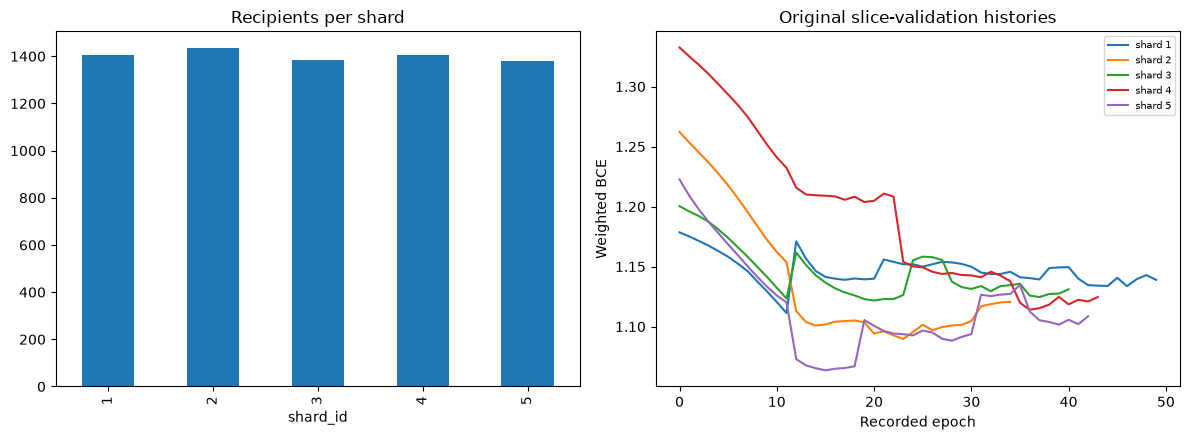

In [54]:
# Keep shard and slice operations explicit so SISA provenance remains auditable.
fig,axes=plt.subplots(1,2,figsize=(12,4.5))
shard_summary.plot.bar(x="shard_id",y="recipients",ax=axes[0],legend=False,title="Recipients per shard")
for shard_id in range(1,N_SHARDS+1):
    part=original_training_history.loc[original_training_history["shard_id"].eq(shard_id)]
    axes[1].plot(np.arange(len(part)),part["validation_weighted_bce"],label=f"shard {shard_id}")
axes[1].set(title="Original slice-validation histories",xlabel="Recorded epoch",ylabel="Weighted BCE")
axes[1].legend(fontsize=7)
fig.tight_layout()
fig.savefig(FIGURE_DIR/"sisa_structure_and_training.png",dpi=160,bbox_inches="tight")
plt.show()

Every deletion scenario affected all five shards from slice 1, so each request replayed all 25 cumulative stages and reused no original final shard model. The request-agnostic assignment spread forgotten records across the full ensemble. This run therefore does not demonstrate SISA's ideal selective-retraining advantage.


# 7. Evaluate retained-data utility

The threshold and individual metric definitions match Notebooks 03 and 04. Each scenario uses only its retained test records.


In [55]:
# Keep threshold 0.62 fixed for all retained-test comparisons.
def binary_metrics(y,p,threshold=THRESHOLD):
    pred=(p>=threshold).astype(int)
    tn,fp,fn,tp=confusion_matrix(y,pred,labels=[0,1]).ravel()
    return {"n":len(y),"positive_count":int(y.sum()),"prevalence":float(y.mean()),"threshold":threshold,
        "pr_auc":average_precision_score(y,p),"auroc":roc_auc_score(y,p),
        "balanced_accuracy":balanced_accuracy_score(y,pred),"f1":f1_score(y,pred,zero_division=0),
        "binary_cross_entropy":log_loss(y,p,labels=[0,1]),"precision":precision_score(y,pred,zero_division=0),
        "recall":recall_score(y,pred,zero_division=0),"specificity":tn/(tn+fp),"accuracy":accuracy_score(y,pred),
        "positive_prediction_rate":float(pred.mean()),"true_negative":int(tn),"false_positive":int(fp),
        "false_negative":int(fn),"true_positive":int(tp)}

test_prediction_rows=[]
sisa_metric_rows=[]


In [56]:
# Aggregate fixed shard outputs to recover the established ensemble prediction.
for scenario in SCENARIOS:
    frame=scenario_frames[scenario]["retained_test"].reset_index(drop=True)
    matrix=preprocessor.transform(frame[features]).astype("float32")
    y=frame[target].to_numpy()
    original=aggregate_models(original_models,matrix)
    updated=scenario_probabilities[scenario]["retained_test"]
    test_prediction_rows.append(pd.DataFrame({"scenario":scenario,"evaluation_row":np.arange(len(frame)),
        "assessment_id":frame["assessment_id"],"true_target":y,"original_sisa_probability":original,
        "updated_sisa_probability":updated,"original_sisa_prediction":(original>=THRESHOLD).astype(int),
        "updated_sisa_prediction":(updated>=THRESHOLD).astype(int)}))
    for method,probability in [("original_sisa",original),("updated_sisa",updated)]:
        sisa_metric_rows.append({"scenario":scenario,"model":method,**binary_metrics(y,probability)})
retained_test_predictions=pd.concat(test_prediction_rows,ignore_index=True)
sisa_metrics=pd.DataFrame(sisa_metric_rows)

`bce_quality = exp(-binary_cross_entropy)`. The safeguarded harmonic mean uses PR-AUC, AUROC, balanced accuracy, F1 and BCE quality unchanged.


In [57]:
# Compare methods on identical scenario-specific retained-test rows.
reference_metrics=gradient_utility_reference.copy()
metric_columns=list(sisa_metrics.columns)
reference_metrics=reference_metrics[metric_columns]
utility_metrics=pd.concat([reference_metrics,sisa_metrics],ignore_index=True)
utility_metrics["bce_quality"]=np.exp(-utility_metrics["binary_cross_entropy"])
components=["pr_auc","auroc","balanced_accuracy","f1","bce_quality"]
def harmonic(values,epsilon=1e-12):
    values=np.asarray(values,dtype=float)
    return float(len(values)/np.sum(1/np.maximum(values,epsilon)))
utility_metrics["composite_model_utility"]=utility_metrics[components].apply(harmonic,axis=1)
composite_model_utility=utility_metrics[["scenario","model",*components,"composite_model_utility"]]
assert np.allclose(composite_model_utility["composite_model_utility"],
                   composite_model_utility[components].apply(harmonic,axis=1),atol=1e-12,rtol=1e-12)

The table includes baseline, full retraining, fine-tuning, gradient ascent, original SISA and updated SISA on identical scenario-specific rows. Full retraining is a single model; SISA is a five-model ensemble.


In [58]:
# Compare utility deltas without using them to alter the partition.
wide=utility_metrics.pivot(index="scenario",columns="model")
delta_rows=[]
delta_metrics=["pr_auc","auroc","balanced_accuracy","f1","binary_cross_entropy","bce_quality","composite_model_utility"]
for scenario in SCENARIOS:
    row={"scenario":scenario}
    for metric in delta_metrics:
        updated=wide.loc[scenario,(metric,"updated_sisa")]
        for reference in ["baseline","full_retraining","fine_tuning","gradient_ascent","original_sisa"]:
            row[f"updated_sisa_minus_{reference}_{metric}"]=updated-wide.loc[scenario,(metric,reference)]
    delta_rows.append(row)
utility_deltas=pd.DataFrame(delta_rows)
display(utility_metrics[["scenario","model",*delta_metrics]])

,scenario,model,pr_auc,auroc,balanced_accuracy,f1,binary_cross_entropy,bce_quality,composite_model_utility
0,recipient_withdrawal,baseline,0.169267,0.731534,0.630478,0.244288,0.574755,0.562843,0.339417
1,donor_withdrawal,baseline,0.168604,0.731754,0.630475,0.244170,0.574600,0.562930,0.338853
2,hospital_removal,baseline,0.173596,0.739196,0.636655,0.252029,0.573226,0.563704,0.346601
3,invalid_consent,baseline,0.163900,0.735045,0.628857,0.237052,0.559673,0.571396,0.332878
4,retention_expiry,baseline,0.167302,0.744495,0.634281,0.252886,0.540615,0.582390,0.343208
5,recipient_withdrawal,full_retraining,0.177118,0.734572,0.628800,0.234677,0.590813,0.553877,0.340965
6,donor_withdrawal,full_retraining,0.173580,0.731609,0.633887,0.236778,0.599383,0.549150,0.338987
7,hospital_removal,full_retraining,0.176205,0.743964,0.641917,0.249229,0.590414,0.554098,0.347360
8,invalid_consent,full_retraining,0.167787,0.735362,0.637605,0.229071,0.595136,0.551488,0.331853
9,retention_expiry,full_retraining,0.162155,0.741491,0.627631,0.227008,0.585620,0.556761,0.326582


Affected shards and replay stages accompany utility so cross-scenario differences remain descriptive.


In [59]:
# Join utility with replay structure to keep the outcomes separate.
scenario_structure=scenario_ensemble_manifest_summary.merge(
    scenario_shard_impact.groupby("scenario")["replayed_slice_stages"].sum().reset_index(),on="scenario")
utility_structure=composite_model_utility.loc[composite_model_utility["model"].eq("updated_sisa")].merge(
    scenario_structure,on="scenario")
display(utility_structure)

,scenario,model,pr_auc,auroc,balanced_accuracy,f1,bce_quality,composite_model_utility,affected_shards,reused_shards,manifest_model_count,replayed_slice_stages
0,recipient_withdrawal,updated_sisa,0.167480,0.720961,0.613098,0.230626,0.562590,0.331071,5,0,5,25
1,donor_withdrawal,updated_sisa,0.164896,0.719449,0.612888,0.228220,0.562908,0.327993,5,0,5,25
2,hospital_removal,updated_sisa,0.166894,0.726118,0.616289,0.234761,0.564292,0.332814,5,0,5,25
3,invalid_consent,updated_sisa,0.158380,0.719450,0.610271,0.216535,0.564700,0.317833,5,0,5,25
4,retention_expiry,updated_sisa,0.159342,0.730887,0.620543,0.230848,0.563258,0.325463,5,0,5,25


Mean Composite Model Utility was `0.326305` for original SISA and `0.326742` after deletion replay, so the updated ensemble preserved its own retained-data utility closely. This is separate from the cross-method result: updated-SISA utility remained lower than the baseline, full retraining, fine-tuning and Gradient Ascent in all five scenarios.


# 8. Evaluate forgetting and compare methods

Every SISA probability averages exactly five shard models. Baseline, full retraining, fine-tuning and gradient ascent are aligned from immutable references.


In [60]:
# Align all methods on the same training-forget records.
def record_bce(y,p):
    p=np.clip(np.asarray(p,dtype=np.float64),1e-15,1-1e-15)
    y=np.asarray(y,dtype=np.float64)
    return -(y*np.log(p)+(1-y)*np.log(1-p))

forget_frames=[]


In [61]:
# Aggregate fixed shard outputs to recover the established ensemble prediction.
for scenario in SCENARIOS:
    frame=scenario_frames[scenario]["training_forget"].reset_index(drop=True)
    matrix=preprocessor.transform(frame[features]).astype("float32")
    y=frame[target].to_numpy()
    ref=gradient_forget.loc[gradient_forget["scenario"].eq(scenario)].sort_values("evaluation_row").reset_index(drop=True)
    probabilities={method:ref[f"{method}_probability"].to_numpy(dtype=np.float64)
        for method in ["baseline","full_retraining","fine_tuning","gradient_ascent"]}
    probabilities["original_sisa"]=aggregate_models(original_models,matrix)
    probabilities["updated_sisa"]=scenario_probabilities[scenario]["training_forget"]
    output=pd.DataFrame({"scenario":scenario,"evaluation_row":np.arange(len(frame)),
                         "assessment_id":frame["assessment_id"],"true_target":y})
    for method,probability in probabilities.items():
        output[f"{method}_probability"]=probability
        output[f"{method}_prediction"]=(probability>=THRESHOLD).astype(int)
        output[f"{method}_per_record_bce"]=record_bce(y,probability)
    forget_frames.append(output)


In [62]:
forget_set_predictions=pd.concat(forget_frames,ignore_index=True)

The established binary truth-ratio definition and epsilon are reused exactly.


In [63]:
# Reuse the established binary Truth Ratio definition unchanged.
truth_frames=[]
for method in ["baseline","full_retraining","fine_tuning","gradient_ascent","original_sisa","updated_sisa"]:
    probability=forget_set_predictions[f"{method}_probability"].to_numpy(dtype=np.float64)
    y=forget_set_predictions["true_target"].to_numpy(dtype=np.int64)
    p_true=np.where(y==1,probability,1-probability)
    p_incorrect=1-p_true
    ratio=(p_incorrect+EPSILON)/(p_true+EPSILON)
    truth_frames.append(pd.DataFrame({"scenario":forget_set_predictions["scenario"],
        "evaluation_row":forget_set_predictions["evaluation_row"],"true_target":y,"model":method,
        "p_true":p_true,"p_incorrect":p_incorrect,"truth_ratio":ratio,"epsilon":EPSILON}))
truth_ratio_values=pd.concat(truth_frames,ignore_index=True)
truth_ratio_summary=truth_ratio_values.groupby(["scenario","model"])["truth_ratio"].agg(
    count="count",mean="mean",median="median",minimum="min",maximum="max",
    q1=lambda x:x.quantile(.25),q3=lambda x:x.quantile(.75)).reset_index()
truth_ratio_summary["interquartile_range"]=truth_ratio_summary["q3"]-truth_ratio_summary["q1"]


In [64]:
display(truth_ratio_summary)

,scenario,model,count,mean,median,minimum,maximum,q1,q3,interquartile_range
0,donor_withdrawal,baseline,1992,0.979881,0.906640,3.574875e-09,6.985770,0.390317,1.388092,0.997774
1,donor_withdrawal,fine_tuning,1992,1.015556,0.917704,3.442744e-09,7.737382,0.381329,1.430981,1.049652
2,donor_withdrawal,full_retraining,1992,1.065314,0.963850,1.271374e-07,7.135536,0.417091,1.516182,1.099091
3,donor_withdrawal,gradient_ascent,1992,1.028508,0.947777,4.375604e-09,7.630473,0.412730,1.448481,1.035751
4,donor_withdrawal,original_sisa,1992,0.970643,0.799864,1.194803e-03,7.010938,0.378420,1.340642,0.962222
5,donor_withdrawal,updated_sisa,1992,0.996856,0.803003,1.235684e-03,8.464731,0.366870,1.389050,1.022180
6,hospital_removal,baseline,4314,0.935517,0.810691,1.652883e-09,8.626322,0.310622,1.343399,1.032777
7,hospital_removal,fine_tuning,4314,0.969649,0.823250,1.504561e-09,9.838072,0.309193,1.390201,1.081007
8,hospital_removal,full_retraining,4314,1.011090,0.882400,4.613736e-09,10.233602,0.308297,1.430740,1.122443
9,hospital_removal,gradient_ascent,4314,1.052714,0.899327,2.670830e-09,10.906833,0.338006,1.494859,1.156853


Two-sided KS tests compare updated SISA with full retraining. Higher p-values mean less evidence of difference; lower statistics mean smaller observed distance. Neither proves equivalence, erasure or privacy.


In [65]:
# Compare updated SISA with each scenario's full-retraining reference.
quality_rows=[]
for scenario in SCENARIOS:
    part=truth_ratio_values.loc[truth_ratio_values["scenario"].eq(scenario)]
    updated=part.loc[part["model"].eq("updated_sisa"),"truth_ratio"]
    full=part.loc[part["model"].eq("full_retraining"),"truth_ratio"]
    result=ks_2samp(updated,full,alternative="two-sided",method="auto")
    quality_rows.append({"scenario":scenario,"forget_rows":len(updated),
        "tofu_style_forget_quality":float(result.pvalue),"ks_statistic":float(result.statistic)})
forget_quality_core=pd.DataFrame(quality_rows)
display(forget_quality_core)

,scenario,forget_rows,tofu_style_forget_quality,ks_statistic
0,recipient_withdrawal,426,1.301308e-04,0.150235
1,donor_withdrawal,1992,1.994542e-10,0.107430
2,hospital_removal,4314,4.133776e-33,0.131896
3,invalid_consent,4148,2.819496e-03,0.039778
4,retention_expiry,6262,1.255609e-06,0.047748


Supporting differences compare updated SISA with full retraining, original SISA, fine-tuning and gradient ascent.


In [66]:
# Retain supporting probability distances without replacing Truth Ratio KS.
support=[]
for scenario in SCENARIOS:
    part=forget_set_predictions.loc[forget_set_predictions["scenario"].eq(scenario)]
    updated=part["updated_sisa_probability"]
    full=part["full_retraining_probability"]
    original=part["original_sisa_probability"]
    support.append({"scenario":scenario,
        "mean_absolute_probability_difference_from_full":np.mean(np.abs(updated-full)),
        "median_absolute_probability_difference_from_full":np.median(np.abs(updated-full)),
        "prediction_agreement_with_full":np.mean(part["updated_sisa_prediction"]==part["full_retraining_prediction"]),
        "mean_absolute_loss_difference_from_full":np.mean(np.abs(part["updated_sisa_per_record_bce"]-part["full_retraining_per_record_bce"])),
        "mean_probability_change_from_original_sisa":np.mean(updated-original),
        "prediction_changed_from_original_sisa_pct":100*np.mean(part["updated_sisa_prediction"]!=part["original_sisa_prediction"]),
        "mean_absolute_probability_difference_from_fine_tuning":np.mean(np.abs(updated-part["fine_tuning_probability"])),
        "mean_absolute_probability_difference_from_gradient_ascent":np.mean(np.abs(updated-part["gradient_ascent_probability"]))})


In [67]:
forget_quality=forget_quality_core.merge(pd.DataFrame(support),on="scenario")

KS statistic is the primary cross-scenario distance and is shown with affected shards and replayed stages.


In [68]:
# Report forgetting distance beside the structural replay cost.
forget_quality=forget_quality.merge(scenario_structure,on="scenario")
display(forget_quality[["scenario","forget_rows","ks_statistic","tofu_style_forget_quality",
                        "affected_shards","replayed_slice_stages"]])

,scenario,forget_rows,ks_statistic,tofu_style_forget_quality,affected_shards,replayed_slice_stages
0,recipient_withdrawal,426,0.150235,1.301308e-04,5,25
1,donor_withdrawal,1992,0.107430,1.994542e-10,5,25
2,hospital_removal,4314,0.131896,4.133776e-33,5,25
3,invalid_consent,4148,0.039778,2.819496e-03,5,25
4,retention_expiry,6262,0.047748,1.255609e-06,5,25


Updated-SISA KS statistics against full retraining were `0.150235`, `0.107430`, `0.131896`, `0.039778` and `0.047748` for recipient withdrawal, donor withdrawal, hospital removal, invalid consent and retention expiry. All five p-values were below `0.05`. Fine-tuning had a lower KS statistic in every scenario; Gradient Ascent was lower in four, while SISA was lower for invalid consent. These differences may reflect deletion behaviour and the structural difference between a five-model ensemble and the monolithic reference, so they do not by themselves prove failed deletion.


Initial SISA preparation is separated from each selective replay. Deletion time is compared with full retraining, fine-tuning and gradient ascent using a descriptive 1.10× meaningful-speedup threshold.


In [69]:
# Compare replay time without including the one-off preparation cost.
efficiency=deletion_time_summary.merge(full_training[["scenario","training_seconds"]].rename(
    columns={"training_seconds":"full_retraining_seconds"}),on="scenario").merge(
    fine_training[["scenario","training_seconds"]].rename(columns={"training_seconds":"fine_tuning_seconds"}),on="scenario").merge(
    gradient_training[["scenario","training_seconds"]].rename(columns={"training_seconds":"gradient_ascent_seconds"}),on="scenario")
for method in ["full_retraining","fine_tuning","gradient_ascent"]:
    efficiency[f"speed_up_vs_{method}"]=efficiency[f"{method}_seconds"]/efficiency["selective_retraining_seconds"]
    efficiency[f"time_reduction_pct_vs_{method}"]=100*(efficiency[f"{method}_seconds"]-
        efficiency["selective_retraining_seconds"])/efficiency[f"{method}_seconds"]
display(efficiency)

,scenario,selective_retraining_seconds,full_retraining_seconds,fine_tuning_seconds,gradient_ascent_seconds,speed_up_vs_full_retraining,time_reduction_pct_vs_full_retraining,speed_up_vs_fine_tuning,time_reduction_pct_vs_fine_tuning,speed_up_vs_gradient_ascent,time_reduction_pct_vs_gradient_ascent
0,recipient_withdrawal,3.638856,3.923029,0.961513,0.082731,1.078094,7.243693,0.264235,-278.451110,0.022735,-4298.441701
1,donor_withdrawal,3.631015,3.450068,1.012794,0.164424,0.950166,-5.244746,0.278929,-258.514772,0.045283,-2108.326581
2,hospital_removal,3.454197,3.847863,0.908232,0.308786,1.113968,10.230785,0.262936,-280.320785,0.089395,-1018.636158
3,invalid_consent,3.449524,3.528170,1.373795,0.370443,1.022799,2.229084,0.398257,-151.094430,0.107390,-831.188784
4,retention_expiry,3.498488,3.111061,3.194244,0.454323,0.889259,-12.453229,0.913036,-9.524756,0.129863,-670.043612


In [70]:
# Treat the speed-up threshold as descriptive only.
MEANINGFUL_SPEEDUP=1.10
def interpret_speed(value):
    if value>=MEANINGFUL_SPEEDUP:return "meaningfully faster"
    if value>1:return "slightly faster, no meaningful advantage"
    if np.isclose(value,1,atol=.01):return "approximately equal"
    return "slower"
runtime_lines=[]
for row in efficiency.itertuples():
    runtime_lines.append(f"- **{row.scenario.replace('_',' ').capitalize()}**: {row.selective_retraining_seconds:.2f}s; "
        f"{row.speed_up_vs_full_retraining:.2f}× vs full retraining ({interpret_speed(row.speed_up_vs_full_retraining)}); "
        f"{row.speed_up_vs_fine_tuning:.2f}× vs fine-tuning ({interpret_speed(row.speed_up_vs_fine_tuning)}); "
        f"{row.speed_up_vs_gradient_ascent:.2f}× vs gradient ascent ({interpret_speed(row.speed_up_vs_gradient_ascent)}).")
runtime_summary="\n".join(runtime_lines)
display(Markdown(runtime_summary))

- **Recipient withdrawal**: 3.64s; 1.08× vs full retraining (slightly faster, no meaningful advantage); 0.26× vs fine-tuning (slower); 0.02× vs gradient ascent (slower).
- **Donor withdrawal**: 3.63s; 0.95× vs full retraining (slower); 0.28× vs fine-tuning (slower); 0.05× vs gradient ascent (slower).
- **Hospital removal**: 3.45s; 1.11× vs full retraining (meaningfully faster); 0.26× vs fine-tuning (slower); 0.09× vs gradient ascent (slower).
- **Invalid consent**: 3.45s; 1.02× vs full retraining (slightly faster, no meaningful advantage); 0.40× vs fine-tuning (slower); 0.11× vs gradient ascent (slower).
- **Retention expiry**: 3.50s; 0.89× vs full retraining (slower); 0.91× vs fine-tuning (slower); 0.13× vs gradient ascent (slower).

Updated SISA, fine-tuning and gradient ascent use distinct markers. Lower KS is better; p-value is not the cross-scenario axis.


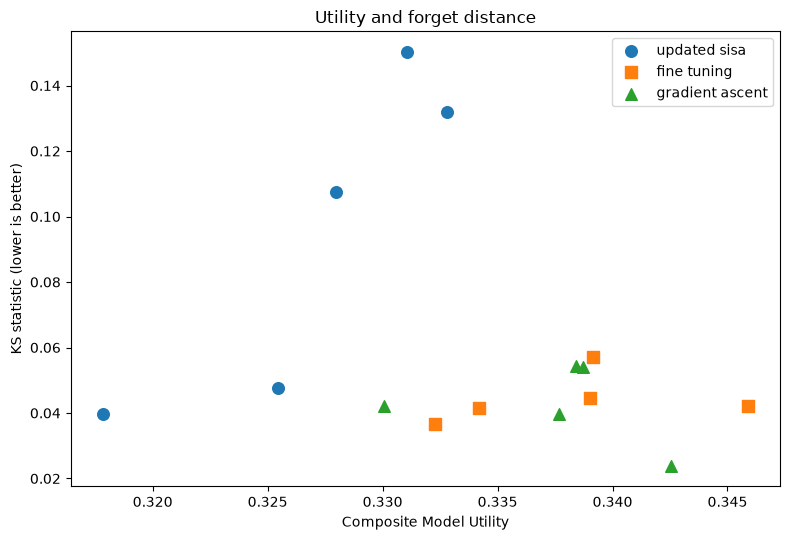

In [71]:
# Plot utility and forgetting as separate outcomes.
trade=[]
for method,quality in [("updated_sisa",forget_quality_core),("fine_tuning",fine_quality),("gradient_ascent",gradient_quality)]:
    utility=composite_model_utility.loc[composite_model_utility["model"].eq(method),
                                        ["scenario","composite_model_utility"]]
    trade.append(utility.merge(quality[["scenario","ks_statistic"]],on="scenario").assign(method=method))
trade_plot=pd.concat(trade,ignore_index=True)
fig,ax=plt.subplots(figsize=(8,5.5))
for method,marker in [("updated_sisa","o"),("fine_tuning","s"),("gradient_ascent","^")]:
    part=trade_plot.loc[trade_plot["method"].eq(method)]
    ax.scatter(part["composite_model_utility"],part["ks_statistic"],marker=marker,s=70,label=method.replace("_"," "))
ax.set(xlabel="Composite Model Utility",ylabel="KS statistic (lower is better)",title="Utility and forget distance")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR/"utility_vs_forget_distance.png",dpi=160,bbox_inches="tight")
plt.show()

The combined table leaves utility, forgetting, replay structure and cost as separate dimensions.


In [72]:
# Keep structural, utility, forgetting and runtime results in one audit table.
updated_composite=composite_model_utility.loc[composite_model_utility["model"].eq("updated_sisa")]
combined_tradeoff=updated_composite.merge(forget_quality,on="scenario").merge(efficiency,on="scenario")
display(combined_tradeoff)

,scenario,model,pr_auc,auroc,balanced_accuracy,f1,bce_quality,composite_model_utility,forget_rows,tofu_style_forget_quality,...,selective_retraining_seconds,full_retraining_seconds,fine_tuning_seconds,gradient_ascent_seconds,speed_up_vs_full_retraining,time_reduction_pct_vs_full_retraining,speed_up_vs_fine_tuning,time_reduction_pct_vs_fine_tuning,speed_up_vs_gradient_ascent,time_reduction_pct_vs_gradient_ascent
0,recipient_withdrawal,updated_sisa,0.167480,0.720961,0.613098,0.230626,0.562590,0.331071,426,1.301308e-04,...,3.638856,3.923029,0.961513,0.082731,1.078094,7.243693,0.264235,-278.451110,0.022735,-4298.441701
1,donor_withdrawal,updated_sisa,0.164896,0.719449,0.612888,0.228220,0.562908,0.327993,1992,1.994542e-10,...,3.631015,3.450068,1.012794,0.164424,0.950166,-5.244746,0.278929,-258.514772,0.045283,-2108.326581
2,hospital_removal,updated_sisa,0.166894,0.726118,0.616289,0.234761,0.564292,0.332814,4314,4.133776e-33,...,3.454197,3.847863,0.908232,0.308786,1.113968,10.230785,0.262936,-280.320785,0.089395,-1018.636158
3,invalid_consent,updated_sisa,0.158380,0.719450,0.610271,0.216535,0.564700,0.317833,4148,2.819496e-03,...,3.449524,3.528170,1.373795,0.370443,1.022799,2.229084,0.398257,-151.094430,0.107390,-831.188784
4,retention_expiry,updated_sisa,0.159342,0.730887,0.620543,0.230848,0.563258,0.325463,6262,1.255609e-06,...,3.498488,3.111061,3.194244,0.454323,0.889259,-12.453229,0.913036,-9.524756,0.129863,-670.043612


Corrected cumulative replay took approximately `6.66–7.09` seconds per scenario. It was about `1.8–2.2×` slower than monolithic full retraining and substantially slower than fine-tuning and Gradient Ascent in this execution. Runtime increased because every cumulative stage trains again on all retained data available up to that slice; with every request replaying all 25 stages, no selective-retraining efficiency was observed.


# 9. Save and verify artefacts

Twenty-five original model-and-optimizer checkpoints and only final affected-shard updates already exist. Original and five scenario manifests use relative paths and exactly five ensemble positions.


In [73]:
# Confirm all cumulative checkpoints and relative manifest paths exist.
assert len(original_checkpoint_paths)==25
assert all("model_state_dict" in torch.load(path,weights_only=False) and
           "optimizer_state_dict" in torch.load(path,weights_only=False) for path in original_checkpoint_paths)
assert all(len(manifest["models"])==5 and all(not Path(item["model_path"]).is_absolute() for item in manifest["models"])
           for manifest in scenario_manifests.values())

Saving and each audit stage are separated. Per-shard probability arrays are represented by canonical float64 fingerprints rather than enormous raw tables.


In [74]:
# Preserve all tables needed to reproduce utility, forgetting and audits.
outputs = {"shard_summary.csv": shard_summary, "slice_summary.csv": slice_summary,
    "assignment_validation.csv": assignment_validation, "original_training_history.csv": original_training_history,
    "original_cumulative_stage_audit.csv": original_cumulative_stage_audit,
    "original_training_summary.csv": original_training_summary, "original_ensemble_predictions.csv": original_ensemble_predictions,
    "scenario_shard_impact.csv": scenario_shard_impact, "selective_retraining_history.csv": selective_retraining_history,
    "selective_retraining_summary.csv": selective_retraining_summary,
    "replay_cumulative_stage_audit.csv": replay_cumulative_stage_audit,
    "scenario_ensemble_manifest_summary.csv": scenario_ensemble_manifest_summary,
    "replay_seed_audit.csv": replay_seed_audit, "delete_first_verification.csv": delete_first_verification,
    "retained_test_predictions.csv": retained_test_predictions, "utility_metrics.csv": utility_metrics,
    "composite_model_utility.csv": composite_model_utility, "utility_deltas.csv": utility_deltas,
    "forget_set_predictions.csv": forget_set_predictions, "truth_ratio_values.csv": truth_ratio_values,
    "truth_ratio_summary.csv": truth_ratio_summary, "forget_quality.csv": forget_quality,
    "efficiency_comparison.csv": efficiency, "combined_tradeoff.csv": combined_tradeoff,
    "shard_probability_fingerprints.csv": shard_probability_fingerprints}


In [75]:
for name, frame in outputs.items():
    frame.to_csv(RESULT_DIR / name, index=False, float_format="%.17g")

In [76]:
# Confirm the saved assignment matches the in-memory mapping.
saved_assignment=pd.read_csv(ASSIGNMENT_PATH)
assignment_readback_pass=saved_assignment.equals(assignment)
assert assignment_readback_pass

In [77]:
# Reproduce the deterministic hash assignment from recipient IDs.
assignment_reproduction_pass = saved_assignment.equals(reproduced)
assignment_report = {"status": "passed" if assignment_reproduction_pass else "failed",
    "rows": len(saved_assignment), "sha256": sha256_file(ASSIGNMENT_PATH),
    "algorithm": "sha256 seed/kind/recipient modulo groups"}
_ = (RESULT_DIR / "assignment_reproduction_report.json").write_text(
    json.dumps(assignment_report, indent=2) + "\n"
)
assert assignment_reproduction_pass

In [78]:
# Confirm full shard/slice coverage and cumulative-stage audits.
coverage_pass=bool(assignment_validation["pass"].all() and len(shard_summary)==5 and len(slice_summary)==25)
cumulative_training_pass = original_cumulative_stage_pass and replay_cumulative_stage_pass
assert coverage_pass and cumulative_training_pass

In [79]:
# Reload every original checkpoint with its optimizer state.
original_checkpoint_reload_pass=True
for path in original_checkpoint_paths:
    checkpoint=torch.load(path,weights_only=False)
    model=BaselineMLP()
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer=torch.optim.AdamW(model.parameters(),lr=LEARNING_RATE,weight_decay=WEIGHT_DECAY)
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    original_checkpoint_reload_pass &= checkpoint["architecture"]==[24,64,32,1]
assert original_checkpoint_reload_pass

In [80]:
# Confirm each scenario manifest resolves five valid constituent models.
manifest_checks=[]
for scenario,manifest in scenario_manifests.items():
    paths=[ROOT/item["model_path"] for item in manifest["models"]]
    manifest_checks.append({"scenario":scenario,"five_models":len(paths)==5,
                            "all_relative":all(not Path(item["model_path"]).is_absolute() for item in manifest["models"]),
                            "all_exist":all(path.is_file() for path in paths)})
manifest_checks=pd.DataFrame(manifest_checks)
manifest_pass=bool(manifest_checks.drop(columns="scenario").to_numpy().all())
assert manifest_pass

In [81]:
# Confirm forgotten rows never entered replay training.
forgotten_exclusion_pass=bool(forgotten_exclusion["pass"].all())
assert forgotten_exclusion_pass

In [82]:
# Reload manifest models independently from saved paths.
def load_manifest_models(manifest):
    models = []
    for item in manifest["models"]:
        checkpoint = torch.load(ROOT / item["model_path"], weights_only=False)
        model = BaselineMLP()
        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        model.eval()
        models.append(model)
    return models

reloaded_models = {scenario: load_manifest_models(manifest)
                   for scenario, manifest in scenario_manifests.items()}


In [83]:
# Keep shard and slice operations explicit so SISA provenance remains auditable.
model_reload_verification = pd.DataFrame([
    {"scenario": scenario, "model_count": len(models), "all_five_models_loaded": len(models) == 5}
    for scenario, models in reloaded_models.items()
])
model_reload_verification.to_csv(RESULT_DIR / "model_reload_verification.csv", index=False)
model_reload_pass = bool(model_reload_verification["all_five_models_loaded"].all())
assert model_reload_pass

In [84]:
# Reproduce each shard probability fingerprint.
fingerprint_rows=[]
for scenario in SCENARIOS:
    for partition in ["retained_validation","retained_test","training_forget"]:
        frame=scenario_frames[scenario][partition]
        matrix=preprocessor.transform(frame[features]).astype("float32")
        aggregate_models(reloaded_models[scenario],matrix,fingerprint_rows,scenario,partition)
reproduced_fingerprints=pd.DataFrame(fingerprint_rows)
fingerprint_pass=reproduced_fingerprints.equals(shard_probability_fingerprints)
assert fingerprint_pass

In [85]:
# Confirm reloaded ensembles reproduce saved probabilities.
ensemble_rows=[]
for scenario in SCENARIOS:
    for partition,column in [("retained_test","updated_sisa_probability"),("training_forget","updated_sisa_probability")]:
        frame=scenario_frames[scenario][partition]
        matrix=preprocessor.transform(frame[features]).astype("float32")
        reproduced_probability=aggregate_models(reloaded_models[scenario],matrix)
        saved_frame=retained_test_predictions if partition=="retained_test" else forget_set_predictions
        saved_probability=saved_frame.loc[saved_frame["scenario"].eq(scenario),column].to_numpy()
        ensemble_rows.append({"scenario":scenario,"partition":partition,
            "maximum_absolute_difference":float(np.max(np.abs(reproduced_probability-saved_probability))),
            "pass":np.allclose(reproduced_probability,saved_probability,atol=1e-8,rtol=1e-8)})
ensemble_probability_reproduction=pd.DataFrame(ensemble_rows)
ensemble_probability_reproduction.to_csv(RESULT_DIR/"ensemble_probability_reproduction.csv",index=False,float_format="%.17g")
ensemble_pass=bool(ensemble_probability_reproduction["pass"].all())
assert ensemble_pass

In [86]:
# Recalculate utility from saved predictions.
saved_predictions = pd.read_csv(RESULT_DIR / "retained_test_predictions.csv")
saved_utility = pd.read_csv(RESULT_DIR / "utility_metrics.csv")
saved_composite = pd.read_csv(RESULT_DIR / "composite_model_utility.csv")
metric_names = ["n", "positive_count", "prevalence", "threshold", "pr_auc", "auroc",
    "balanced_accuracy", "f1", "binary_cross_entropy", "precision", "recall", "specificity",
    "accuracy", "positive_prediction_rate", "true_negative", "false_positive", "false_negative", "true_positive"]
reproduction_rows = []


In [87]:
# Aggregate fixed shard outputs to recover the established ensemble prediction.
for scenario in SCENARIOS:
    predictions = saved_predictions.loc[saved_predictions["scenario"].eq(scenario)]
    for model, probability_column in [("original_sisa", "original_sisa_probability"),
                                      ("updated_sisa", "updated_sisa_probability")]:
        calculated = binary_metrics(
            predictions["true_target"].to_numpy(), predictions[probability_column].to_numpy()
        )
        saved_row = saved_utility.loc[
            saved_utility["scenario"].eq(scenario) & saved_utility["model"].eq(model)
        ].iloc[0]
        for metric in metric_names:
            expected, actual = float(saved_row[metric]), float(calculated[metric])
            tolerance = 0.0 if metric in {"n", "positive_count", "true_negative", "false_positive",
                                           "false_negative", "true_positive"} else 1e-8
            reproduction_rows.append({"scenario": scenario, "model": model, "metric": metric,
                "saved_value": expected, "recalculated_value": actual, "absolute_difference": abs(expected - actual),
                "tolerance": tolerance, "pass": bool(np.isclose(expected, actual, atol=tolerance, rtol=0))})

In [88]:
# Recalculate each saved metric from persisted probabilities.
for scenario in SCENARIOS:
    for model in ["original_sisa", "updated_sisa"]:
        saved_row = saved_utility.loc[
            saved_utility["scenario"].eq(scenario) & saved_utility["model"].eq(model)
        ].iloc[0]
        saved_composite_row = saved_composite.loc[
            saved_composite["scenario"].eq(scenario) & saved_composite["model"].eq(model)
        ].iloc[0]
        bce_quality = float(np.exp(-saved_row["binary_cross_entropy"]))
        composite = harmonic([saved_row["pr_auc"], saved_row["auroc"], saved_row["balanced_accuracy"],
                              saved_row["f1"], bce_quality])
        for metric, expected, actual in [
            ("bce_quality", saved_composite_row["bce_quality"], bce_quality),
            ("composite_model_utility", saved_composite_row["composite_model_utility"], composite),
        ]:
            reproduction_rows.append({"scenario": scenario, "model": model, "metric": metric,
                "saved_value": float(expected), "recalculated_value": float(actual),
                "absolute_difference": abs(float(expected) - float(actual)), "tolerance": 1e-8,
                "pass": bool(np.isclose(expected, actual, atol=1e-8, rtol=0))})


In [89]:
# Keep shard and slice operations explicit so SISA provenance remains auditable.
utility_metric_reproduction = pd.DataFrame(reproduction_rows)
utility_metric_reproduction.to_csv(
    RESULT_DIR / "utility_metric_reproduction.csv", index=False, float_format="%.17g"
)
base_metric_pass = bool(utility_metric_reproduction.loc[
    ~utility_metric_reproduction["metric"].isin(["bce_quality", "composite_model_utility"]), "pass"].all())
composite_utility_reproduction_pass = bool(utility_metric_reproduction.loc[
    utility_metric_reproduction["metric"].isin(["bce_quality", "composite_model_utility"]), "pass"].all())
utility_reproduction_pass = base_metric_pass and composite_utility_reproduction_pass
assert utility_reproduction_pass

In [90]:
# Reproduce Truth Ratio from persisted probability components.
saved_truth=pd.read_csv(RESULT_DIR/"truth_ratio_values.csv")
reproduced_ratio=(saved_truth["p_incorrect"]+saved_truth["epsilon"])/(saved_truth["p_true"]+saved_truth["epsilon"])
ratio_difference=np.abs(saved_truth["truth_ratio"]-reproduced_ratio)
truth_ratio_pass=bool(np.allclose(saved_truth["truth_ratio"],reproduced_ratio,atol=1e-8,rtol=0))
truth_ratio_diagnostic=pd.DataFrame([{"rows":len(saved_truth),"maximum_absolute_difference":float(ratio_difference.max()),
                                     "required_tolerance":1e-8,"pass":truth_ratio_pass}])
truth_ratio_diagnostic.to_csv(RESULT_DIR/"truth_ratio_reproduction_diagnostic.csv",index=False,float_format="%.17g")
assert truth_ratio_pass

In [91]:
# Reproduce KS statistics and p-values from saved ratios.
saved_quality=pd.read_csv(RESULT_DIR/"forget_quality.csv").set_index("scenario")
ks_pass=True
for scenario in SCENARIOS:
    part=saved_truth.loc[saved_truth["scenario"].eq(scenario)]
    result=ks_2samp(part.loc[part["model"].eq("updated_sisa"),"truth_ratio"],
                    part.loc[part["model"].eq("full_retraining"),"truth_ratio"])
    ks_pass &= np.isclose(result.statistic,saved_quality.loc[scenario,"ks_statistic"],atol=1e-12,rtol=1e-12)
    ks_pass &= np.isclose(result.pvalue,saved_quality.loc[scenario,"tofu_style_forget_quality"],atol=1e-12,rtol=1e-12)
assert ks_pass

In [92]:
# Keep the baseline threshold and approved feature order unchanged.
threshold_feature_pass=THRESHOLD==.62 and features==baseline_config["classifier_features"] and direct_fields.isdisjoint(features)
assert threshold_feature_pass

In [93]:
# Confirm identifiers, assignments and targets remain outside model inputs.
leakage_fields = direct_fields | {target, "membership_type"}
target_absent_from_features = target not in features
leakage_pass = (leakage_fields.isdisjoint(features)
                and {"shard_id", "slice_id"}.isdisjoint(features)
                and target_absent_from_features)
assert target_absent_from_features and leakage_pass

In [94]:
# Confirm every protected input remains byte-identical.
input_hashes_after = {path.relative_to(ROOT).as_posix(): sha256_file(path) for path in protected_paths}
protected_hash_pass = input_hashes_before == input_hashes_after
original_hashes_after = {path.name: sha256_file(path) for path in original_checkpoint_paths}
unchanged_original_shards_pass = original_checkpoint_hashes == original_hashes_after
artifact_integrity = {"protected_inputs_unchanged": protected_hash_pass,
    "original_checkpoints_unchanged_after_replay": unchanged_original_shards_pass,
    "protected_file_count": len(input_hashes_before), "before": input_hashes_before, "after": input_hashes_after}
_ = (RESULT_DIR / "artifact_integrity_report.json").write_text(
    json.dumps(artifact_integrity, indent=2) + "\n"
)
assert protected_hash_pass and unchanged_original_shards_pass

In [95]:
# Require every isolated SISA artifact before completion.
required = [ASSIGNMENT_PATH, ORIGINAL_DIR / "ensemble_manifest.json", ORIGINAL_DIR / "configuration.json",
    RESULT_DIR / "assignment_reproduction_report.json", RESULT_DIR / "artifact_integrity_report.json",
    RESULT_DIR / "model_reload_verification.csv", RESULT_DIR / "ensemble_probability_reproduction.csv",
    RESULT_DIR / "truth_ratio_reproduction_diagnostic.csv", RESULT_DIR / "utility_metric_reproduction.csv",
    RESULT_DIR / "replay_seed_audit.csv", RESULT_DIR / "delete_first_verification.csv",
    FIGURE_DIR / "sisa_structure_and_training.png", FIGURE_DIR / "utility_vs_forget_distance.png",
    RESULT_DIR / "run_summary.json"]
required += [RESULT_DIR / name for name in outputs]
required += original_checkpoint_paths
required += [UNLEARNED_DIR / scenario / name for scenario in SCENARIOS
             for name in ["ensemble_manifest.json", "configuration.json"]]
required_artifact_pass = all(path.is_file() for path in required)
assert required_artifact_pass

In [96]:
# Require all methodological and numerical checks to pass.
acceptance = pd.DataFrame([
    {"requirement": "Dependency and alignment gate", "pass": bool(artifact_checks["pass"].all())},
    {"requirement": "Assignment readback and reproduction", "pass": assignment_readback_pass and assignment_reproduction_pass},
    {"requirement": "Shard/slice coverage", "pass": coverage_pass},
    {"requirement": "Original cumulative stages and class weights", "pass": original_cumulative_stage_pass},
    {"requirement": "Retained cumulative replay and class weights", "pass": replay_cumulative_stage_pass},
    {"requirement": "Original checkpoints and manifests", "pass": original_checkpoint_reload_pass and manifest_pass},
    {"requirement": "Corrected deterministic delete-first replay", "pass": delete_first_verification_pass and replay_seed_audit_pass},
    {"requirement": "Forgotten-row exclusion", "pass": forgotten_exclusion_pass},
    {"requirement": "Model, fingerprint and ensemble reproduction", "pass": model_reload_pass and fingerprint_pass and ensemble_pass},
    {"requirement": "Saved utility and composite reproduction", "pass": utility_reproduction_pass},
    {"requirement": "Truth-ratio and KS reproduction", "pass": truth_ratio_pass and ks_pass},
    {"requirement": "Threshold, features and leakage", "pass": threshold_feature_pass and leakage_pass and target_absent_from_features},
    {"requirement": "Protected and original hashes", "pass": protected_hash_pass and unchanged_original_shards_pass},
    {"requirement": "Required artifacts", "pass": required_artifact_pass},
])


In [97]:
acceptance["status"] = acceptance["pass"].map({True: "PASS", False: "FAIL"})
display(acceptance.drop(columns="pass"))
assert acceptance["pass"].all()

,requirement,status
0,Dependency and alignment gate,PASS
1,Assignment readback and reproduction,PASS
2,Shard/slice coverage,PASS
3,Original cumulative stages and class weights,PASS
4,Retained cumulative replay and class weights,PASS
5,Original checkpoints and manifests,PASS
6,Corrected deterministic delete-first replay,PASS
7,Forgotten-row exclusion,PASS
8,"Model, fingerprint and ensemble reproduction",PASS
9,Saved utility and composite reproduction,PASS


The final checks reload saved models and tables, reproduce ensemble probabilities and metrics, and confirm that protected inputs remain unchanged.


In [98]:
# Replay only the affected shard suffix while preserving the frozen assignment.
max_reload=ensemble_probability_reproduction["maximum_absolute_difference"].max()
display(Markdown(f"All **{len(acceptance)}** final acceptance requirements passed. Assignment, 25 original "
    f"checkpoints, five scenario manifests, replay exclusion, shard fingerprints and ensemble probabilities reproduced. "
    f"Maximum ensemble reload difference was **{max_reload:.2e}**; utility, truth ratios, KS and protected hashes reconciled."))

All **14** final acceptance requirements passed. Assignment, 25 original checkpoints, five scenario manifests, replay exclusion, shard fingerprints and ensemble probabilities reproduced. Maximum ensemble reload difference was **0.00e+00**; utility, truth ratios, KS and protected hashes reconciled.

# 10. Findings and limitations

The corrected SISA implementation trains cumulative shard checkpoints and excludes forgotten training rows from cumulative replay and its class weights. Post-deletion utility remained close to original-SISA utility, but SISA utility was lower than the other compared methods in every scenario. Forgetting similarity to the monolithic full-retraining reference was mixed and architecture-sensitive: fine-tuning was closer under KS in all five scenarios, Gradient Ascent in four, and SISA for invalid consent.

Cumulative SISA was relatively slow here because every request affected all five shards from slice 1 and replayed all 25 stages. The experiment therefore shows no selective-retraining advantage and remains a backup, exploratory comparison rather than evidence that SISA is the preferred method.


**Limitations.**

This generated-data study uses one split, seed and SISA configuration. The five-shard/five-slice choice, hash assignment and artificial slice order affect results. In this execution every distributed deletion request reached all five randomly assigned recipient shards at slice 1, so all 25 stages were replayed and no original final shard was reused. This is five-shard delete-first retraining, not evidence of substantial selective reuse; observed runtime differences may arise from five smaller models, training dynamics or early stopping.

The monolithic full-retraining reference is one model, while SISA is a five-model ensemble, so their architectures and training procedures are not identical. The common truth-ratio KS comparison is informative but cannot isolate deletion fidelity from that architecture difference. Poor SISA/full-retraining similarity does not prove that deleted data remain memorised. The shared baseline preprocessor is not unlearned. Full retraining remains a heuristic reference; binary TOFU adaptation and KS tests have limitations and do not prove privacy. No privacy attack or parameter analysis is performed. Runtime is hardware-dependent, composite utility can obscure individual metrics, and no causal or clinical claim is made.

**Role in the wider project.**

Notebook 05 is retained as a backup, exploratory SISA comparison. It does not alter the frozen main study in Notebooks 01–04 and does not establish SISA as the preferred unlearning method.

In [99]:
# Write completed status only after acceptance succeeds.
assert acceptance["pass"].all() and required_artifact_pass and protected_hash_pass


In [100]:
# Replay only the affected shard suffix while preserving the frozen assignment.
run_summary = {"status": "completed", "task": "SISA", "seed": SEED, "threshold": THRESHOLD,
    "configuration": original_configuration, "preparation_seconds": preparation_seconds,
    "original_checkpoint_count": 25, "original_storage_bytes": original_storage_bytes,
    "updated_storage_bytes": updated_storage_bytes,
    "total_model_storage_bytes": original_storage_bytes + updated_storage_bytes,
    "slice_training_seed_definition": "derived_seed('slice_training', shard_id, slice_id)",
    "slice_training_seeds": slice_training_seeds,
    "original_cumulative_stage_pass": original_cumulative_stage_pass,
    "replay_cumulative_stage_pass": replay_cumulative_stage_pass,
    "replay_seed_audit_pass": replay_seed_audit_pass,
    "delete_first_verification_pass": delete_first_verification_pass,
    "affected_shards": dict(zip(scenario_ensemble_manifest_summary["scenario"],
                                scenario_ensemble_manifest_summary["affected_shards"])),
    "replayed_slice_stages": scenario_shard_impact.groupby("scenario")["replayed_slice_stages"].sum().to_dict(),
    "deletion_seconds": deletion_time.to_dict(), "all_models_verified": model_reload_pass,
    "utility_metrics_reproduced": base_metric_pass,
    "composite_utility_reproduced": composite_utility_reproduction_pass,
    "maximum_ensemble_probability_difference": float(max_reload), "all_verification_checks_pass": True,
    "protected_inputs_unchanged": protected_hash_pass,
    "original_checkpoints_unchanged": unchanged_original_shards_pass, "network_requests": 0}


In [101]:
_ = (RESULT_DIR / "run_summary.json").write_text(json.dumps(run_summary, indent=2) + "\n")

# Results

## 1. Utility by Deletion Scenario

| Scenario | Model | PR-AUC ↑ | Balanced Accuracy ↑ | BCE ↓ | F1 ↑ | AUROC ↑ | Composite Utility ↑ |
| --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| Recipient Withdrawal | Baseline | 0.1693 | 0.6305 | 0.5748 | 0.2443 | 0.7315 | 0.3394 |
| Recipient Withdrawal | Full Retraining | 0.1771 | 0.6288 | 0.5908 | 0.2347 | 0.7346 | 0.3410 |
| Recipient Withdrawal | Standard SISA | 0.1675 | 0.6131 | 0.5752 | 0.2306 | 0.7210 | 0.3311 |
| Donor Withdrawal | Baseline | 0.1686 | 0.6305 | 0.5746 | 0.2442 | 0.7318 | 0.3389 |
| Donor Withdrawal | Full Retraining | 0.1736 | 0.6339 | 0.5994 | 0.2368 | 0.7316 | 0.3390 |
| Donor Withdrawal | Standard SISA | 0.1649 | 0.6129 | 0.5746 | 0.2282 | 0.7194 | 0.3280 |
| Hospital Removal | Baseline | 0.1736 | 0.6367 | 0.5732 | 0.2520 | 0.7392 | 0.3466 |
| Hospital Removal | Full Retraining | 0.1762 | 0.6419 | 0.5904 | 0.2492 | 0.7440 | 0.3474 |
| Hospital Removal | Standard SISA | 0.1669 | 0.6163 | 0.5722 | 0.2348 | 0.7261 | 0.3328 |
| Invalid Consent | Baseline | 0.1639 | 0.6289 | 0.5597 | 0.2371 | 0.7350 | 0.3329 |
| Invalid Consent | Full Retraining | 0.1678 | 0.6376 | 0.5951 | 0.2291 | 0.7354 | 0.3319 |
| Invalid Consent | Standard SISA | 0.1584 | 0.6103 | 0.5715 | 0.2165 | 0.7194 | 0.3178 |
| Retention Expiry | Baseline | 0.1673 | 0.6343 | 0.5406 | 0.2529 | 0.7445 | 0.3432 |
| Retention Expiry | Full Retraining | 0.1622 | 0.6276 | 0.5856 | 0.2270 | 0.7415 | 0.3266 |
| Retention Expiry | Standard SISA | 0.1593 | 0.6205 | 0.5740 | 0.2308 | 0.7309 | 0.3255 |

Composite Utility is a supporting summary metric; individual utility metrics remain visible.

## 2. Forgetting

| Scenario | Training Forget Rows | KS Statistic ↓ | KS p-value | Mean TR: Standard SISA | Mean TR: Full Retraining |
| --- | ---: | ---: | ---: | ---: | ---: |
| Recipient Withdrawal | 426 | 0.1502 | 0.0001301 | 0.8963 | 0.9515 |
| Donor Withdrawal | 1,992 | 0.1074 | 1.995e-10 | 0.9969 | 1.0653 |
| Hospital Removal | 4,314 | 0.1319 | 4.134e-33 | 0.9306 | 1.0111 |
| Invalid Consent | 4,148 | 0.0398 | 0.002819 | 1.2211 | 1.2611 |
| Retention Expiry | 6,262 | 0.0477 | 1.256e-06 | 1.5129 | 1.4427 |
| Mean | — | 0.0954 | Not averaged | 1.1115 | 1.1463 |

The KS statistic is the primary distribution-distance measure. Its p-value does not prove equivalence, erasure or privacy.

## 3. SISA Replay / Efficiency

| Scenario | Affected Shards ↓ | Replay Stages ↓ | Reused Final Shards ↑ | SISA Runtime (s) | Full Retraining Runtime (s) | Speed-Up ↑ |
| --- | ---: | ---: | ---: | ---: | ---: | ---: |
| Recipient Withdrawal | 5 | 25 | 0 | 3.978 | 3.893 | 0.98× |
| Donor Withdrawal | 5 | 25 | 0 | 3.697 | 3.402 | 0.92× |
| Hospital Removal | 5 | 25 | 0 | 3.494 | 3.839 | 1.10× |
| Invalid Consent | 5 | 25 | 0 | 3.503 | 3.453 | 0.99× |
| Retention Expiry | 5 | 25 | 0 | 3.573 | 3.201 | 0.90× |
| Mean | 5.0000 | 25.0000 | 0.0000 | 3.649 | 3.558 | 0.97× |

## 4. Average Across All Five Scenarios

| Model | Mean PR-AUC ↑ | Mean Balanced Accuracy ↑ | Mean BCE ↓ | Mean F1 ↑ | Mean AUROC ↑ | Mean Composite Utility ↑ |
| --- | ---: | ---: | ---: | ---: | ---: | ---: |
| Baseline | 0.1685 | 0.6321 | 0.5646 | 0.2461 | 0.7364 | 0.3402 |
| Full Retraining | 0.1714 | 0.6340 | 0.5923 | 0.2354 | 0.7374 | 0.3371 |
| Standard SISA | 0.1634 | 0.6146 | 0.5735 | 0.2282 | 0.7234 | 0.3270 |

| SISA Summary | Mean |
| --- | ---: |
| KS Statistic ↓ | 0.0954 |
| Affected Shards ↓ | 5.0000 |
| Replay Stages ↓ | 25.0000 |
| Reused Final Shards ↑ | 0.0000 |
| SISA Runtime (s) ↓ | 3.649 |
| Full Retraining Runtime (s) ↓ | 3.558 |
| Speed-Up ↑ | 0.97× |


## Key Findings

- Standard SISA achieved mean Composite Utility **0.3270** and mean KS distance **0.0954**.
- Mean replay involved **5.0** affected shards and **25.0** replay stages.
- Mean recorded SISA runtime was **3.649 seconds**, versus **3.558 seconds** for Full Retraining.
- These results describe behavioural proximity to Full Retraining, not certified deletion.
